In [3]:
# ===============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ===============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10,6)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


carga del datase

In [4]:
# Cargar el dataset
df = pd.read_csv("adult_income.csv")

print("Dataset cargado correctamente.\n")

df.head()

Dataset cargado correctamente.



,Age,Workclass,fnlwgt,Education,Education_num,Marital_status,Occupation,Relationship,Race,Sex,Capital_gain,Capital_loss,Hours_per_week,Native_country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Información general

In [5]:
print("="*60)
print("DIMENSIONES DEL DATASET")
print("="*60)

print(f"Registros : {df.shape[0]}")
print(f"Columnas  : {df.shape[1]}")

DIMENSIONES DEL DATASET
Registros : 32561
Columnas  : 15


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             32561 non-null  int64
 1   Workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   Education       32561 non-null  str  
 4   Education_num   32561 non-null  int64
 5   Marital_status  32561 non-null  str  
 6   Occupation      32561 non-null  str  
 7   Relationship    32561 non-null  str  
 8   Race            32561 non-null  str  
 9   Sex             32561 non-null  str  
 10  Capital_gain    32561 non-null  int64
 11  Capital_loss    32561 non-null  int64
 12  Hours_per_week  32561 non-null  int64
 13  Native_country  32561 non-null  str  
 14  Income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


LISTA DE VARIABLES

In [7]:
for i, columna in enumerate(df.columns, start=1):
    print(f"{i}. {columna}")

1. Age
2. Workclass
3. fnlwgt
4. Education
5. Education_num
6. Marital_status
7. Occupation
8. Relationship
9. Race
10. Sex
11. Capital_gain
12. Capital_loss
13. Hours_per_week
14. Native_country
15. Income


TIPOS DE DATOS

In [8]:
df.dtypes

Age               int64
Workclass           str
fnlwgt            int64
Education           str
Education_num     int64
Marital_status      str
Occupation          str
Relationship        str
Race                str
Sex                 str
Capital_gain      int64
Capital_loss      int64
Hours_per_week    int64
Native_country      str
Income              str
dtype: object

calidad de datos

In [9]:
# ===============================================================
# BLOQUE 3
# CALIDAD DE LOS DATOS
# Objetivo:
# Revisar valores faltantes, valores con símbolo '?' y duplicados.
# ===============================================================

print("="*60)
print("VALORES NULOS")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("VALORES '?' POR COLUMNA")
print("="*60)
for col in df.columns:
    cantidad = (df[col] == "?").sum()
    if cantidad > 0:
        print(f"{col}: {cantidad}")

print("\n" + "="*60)
print("REGISTROS DUPLICADOS")
print("="*60)
print("Duplicados:", df.duplicated().sum())

VALORES NULOS
Age               0
Workclass         0
fnlwgt            0
Education         0
Education_num     0
Marital_status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital_gain      0
Capital_loss      0
Hours_per_week    0
Native_country    0
Income            0
dtype: int64

VALORES '?' POR COLUMNA
Workclass: 1836
Occupation: 1843
Native_country: 583

REGISTROS DUPLICADOS
Duplicados: 24


In [10]:
# ===============================================================
# BLOQUE 4
# DISTRIBUCIÓN DEL TARGET
# Objetivo:
# Conocer si la variable objetivo está balanceada o desbalanceada.
# ===============================================================

target = "Income"

conteo_target = df[target].value_counts()
porcentaje_target = df[target].value_counts(normalize=True) * 100

tabla_target = pd.DataFrame({
    "Cantidad": conteo_target,
    "Porcentaje": porcentaje_target.round(2)
})

tabla_target

,Cantidad,Porcentaje
Income,,
<=50K,24720,75.92
>50K,7841,24.08


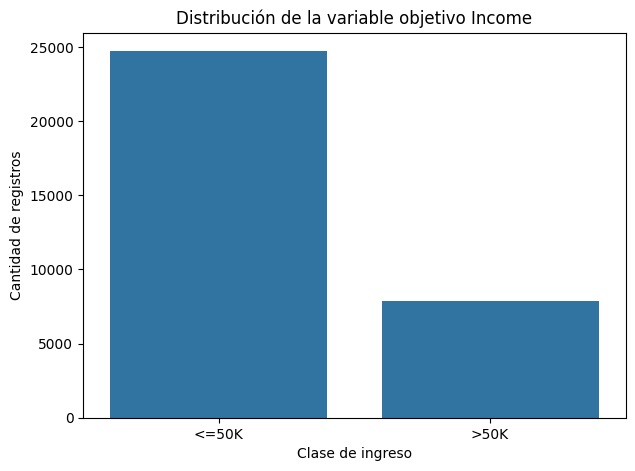

In [11]:
# Gráfico de distribución del target

plt.figure(figsize=(7,5))
sns.countplot(data=df, x=target)
plt.title("Distribución de la variable objetivo Income")
plt.xlabel("Clase de ingreso")
plt.ylabel("Cantidad de registros")
plt.show()

<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<Análisis Exploratorio de Datos (EDA).>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

In [12]:
# ===============================================================
# FASE II - EDA
# BLOQUE 1
# ESTADÍSTICAS DESCRIPTIVAS
# ===============================================================

print("="*70)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*70)

df.describe().T

ESTADÍSTICAS DESCRIPTIVAS


,count,mean,std,min,25%,50%,75%,max
Age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
Education_num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
Capital_gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
Capital_loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
Hours_per_week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


Las estadísticas descriptivas muestran que el dataset contiene variables numéricas con diferentes escalas de valores. La edad de las personas presenta un promedio de 38.58 años, con edades comprendidas entre 17 y 90 años. Asimismo, la variable Hours_per_week indica que, en promedio, las personas trabajan aproximadamente 40 horas por semana, siendo este también el valor de la mediana. Por otro lado, variables como Capital_gain y Capital_loss presentan una alta dispersión, ya que la mayoría de los registros tienen valores iguales a cero, mientras que algunos pocos alcanzan valores muy elevados.

Distribución de las Variables Numéricas

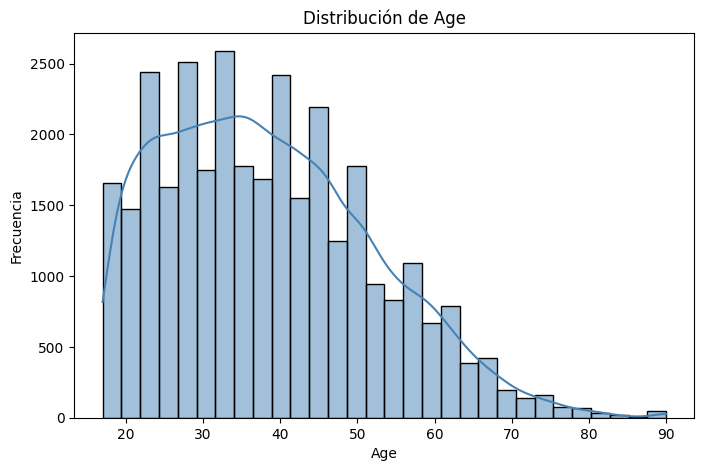

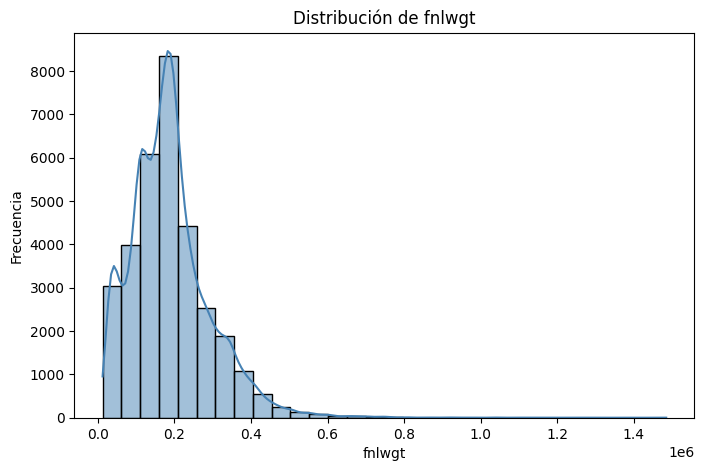

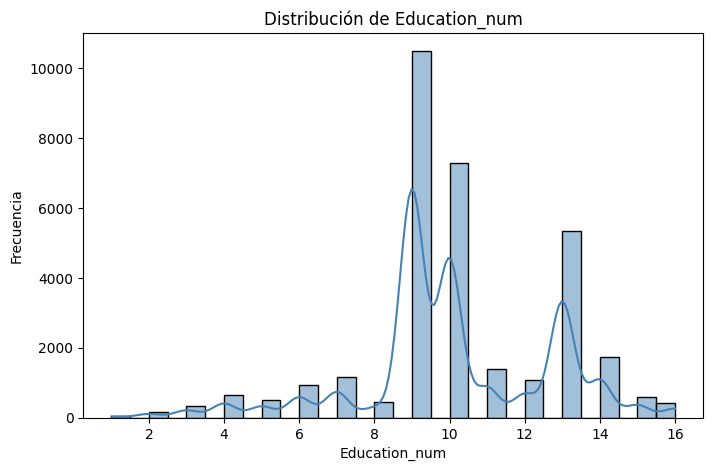

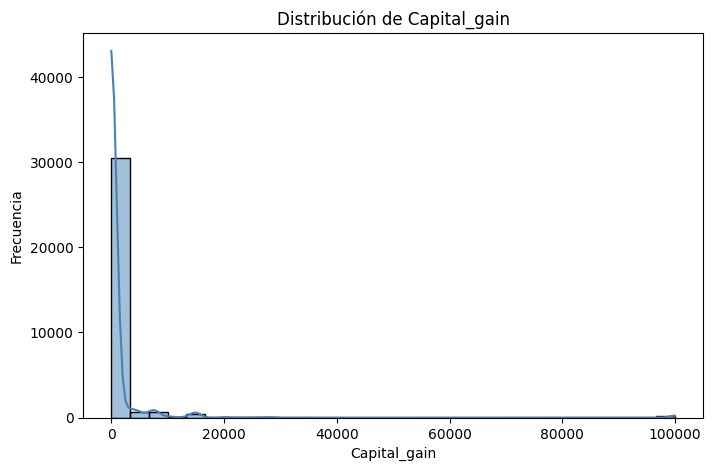

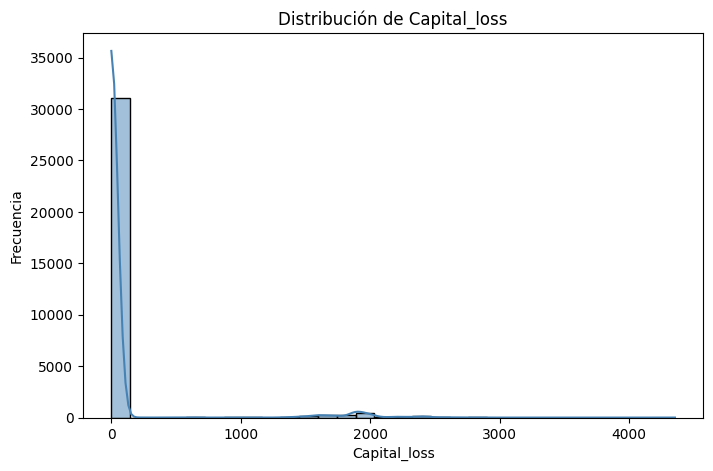

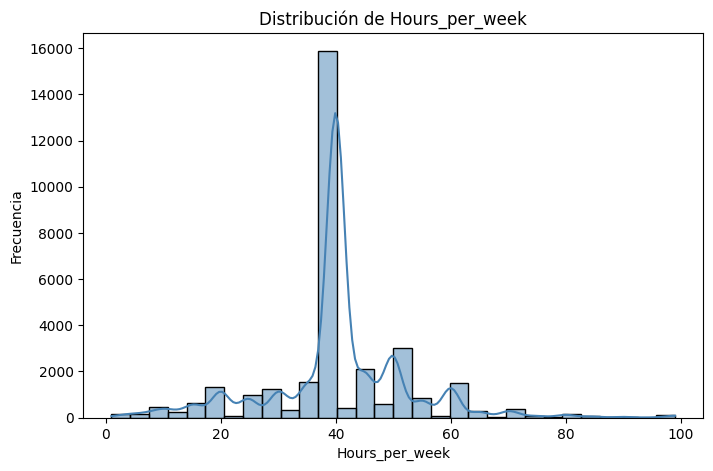

In [13]:
# ===============================================================
# FASE II - EDA
# BLOQUE 2
# DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
# ===============================================================

# Variables numéricas
variables_numericas = [
    "Age",
    "fnlwgt",
    "Education_num",
    "Capital_gain",
    "Capital_loss",
    "Hours_per_week"
]

# Crear histogramas
for variable in variables_numericas:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=variable,
        bins=30,
        kde=True,
        color="steelblue"
    )

    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")

    plt.show()

La mayor parte de las personas registradas tiene edades entre 20 y 50 años, siendo el intervalo entre 30 y 40 años el que concentra la mayor cantidad de registros. A medida que aumenta la edad, la cantidad de personas disminuye, por lo que la distribución presenta una ligera inclinación hacia la derecha.

Distribución de las Variables Categóricas

C:\Users\Haand\AppData\Local\Temp\ipykernel_11344\3202827982.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


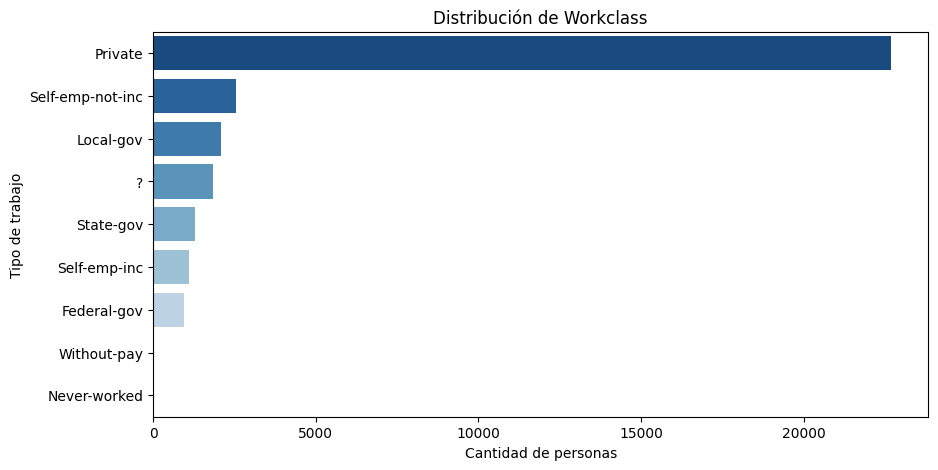

In [14]:
# ===============================================================
# FASE II - EDA
# BLOQUE 3.1
# DISTRIBUCIÓN DE WORKCLASS
# ===============================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Workclass",
    order=df["Workclass"].value_counts().index,
    palette="Blues_r"
)

plt.title("Distribución de Workclass")
plt.xlabel("Cantidad de personas")
plt.ylabel("Tipo de trabajo")

plt.show()

C:\Users\Haand\AppData\Local\Temp\ipykernel_11344\3027999210.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


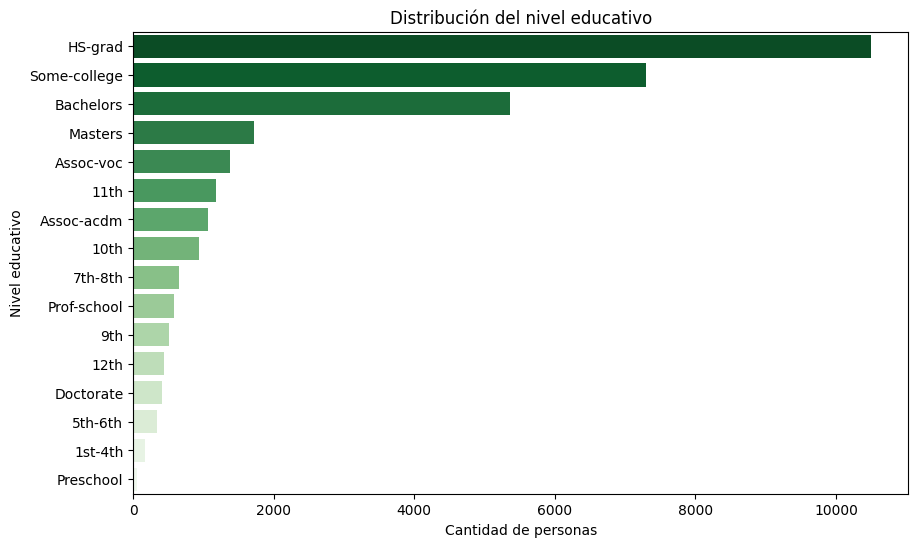

In [15]:
# ===============================================================
# DISTRIBUCIÓN DE EDUCATION
# ===============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="Education",
    order=df["Education"].value_counts().index,
    palette="Greens_r"
)

plt.title("Distribución del nivel educativo")
plt.xlabel("Cantidad de personas")
plt.ylabel("Nivel educativo")

plt.show()

C:\Users\Haand\AppData\Local\Temp\ipykernel_11344\700593682.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


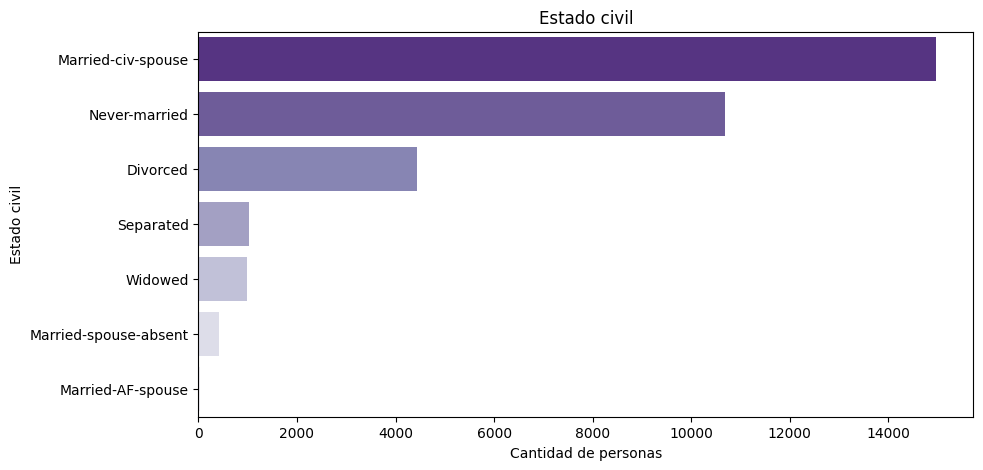

In [16]:
# ===============================================================
# DISTRIBUCIÓN DE MARITAL STATUS
# ===============================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Marital_status",
    order=df["Marital_status"].value_counts().index,
    palette="Purples_r"
)

plt.title("Estado civil")
plt.xlabel("Cantidad de personas")
plt.ylabel("Estado civil")

plt.show()

C:\Users\Haand\AppData\Local\Temp\ipykernel_11344\780255012.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


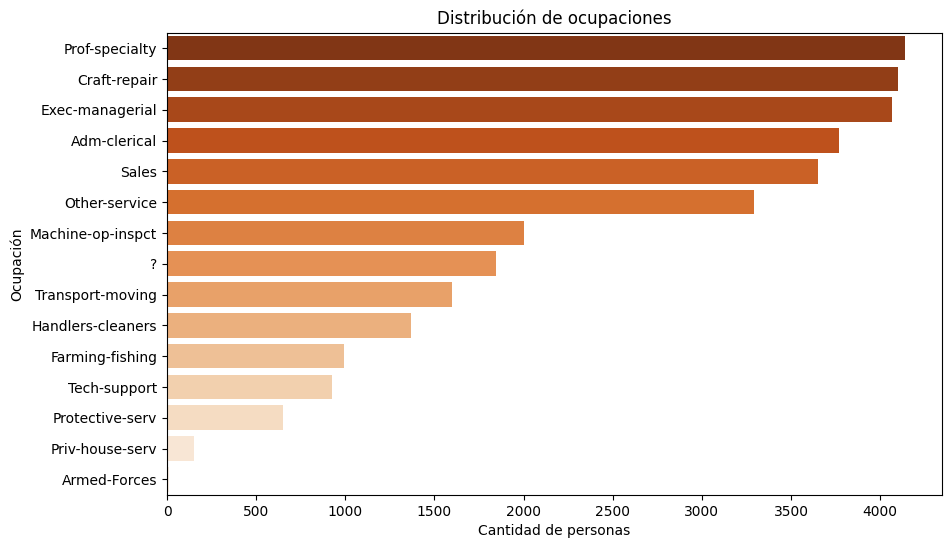

In [17]:
# ===============================================================
# DISTRIBUCIÓN DE OCCUPATION
# ===============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="Occupation",
    order=df["Occupation"].value_counts().index,
    palette="Oranges_r"
)

plt.title("Distribución de ocupaciones")
plt.xlabel("Cantidad de personas")
plt.ylabel("Ocupación")

plt.show()

C:\Users\Haand\AppData\Local\Temp\ipykernel_11344\862009159.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


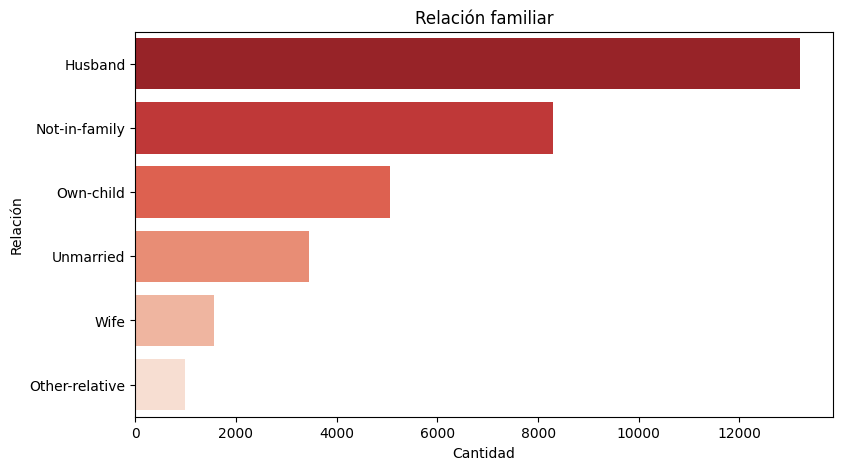

In [18]:
# ===============================================================
# DISTRIBUCIÓN DE RELATIONSHIP
# ===============================================================

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    y="Relationship",
    order=df["Relationship"].value_counts().index,
    palette="Reds_r"
)

plt.title("Relación familiar")
plt.xlabel("Cantidad")
plt.ylabel("Relación")

plt.show()

C:\Users\Haand\AppData\Local\Temp\ipykernel_11344\3999021025.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


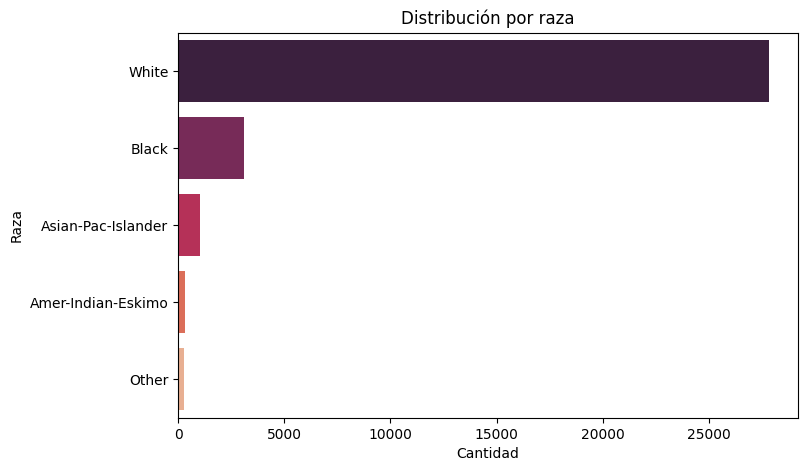

In [19]:
# ===============================================================
# DISTRIBUCIÓN DE RACE
# ===============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="Race",
    order=df["Race"].value_counts().index,
    palette="rocket"
)

plt.title("Distribución por raza")
plt.xlabel("Cantidad")
plt.ylabel("Raza")

plt.show()

C:\Users\Haand\AppData\Local\Temp\ipykernel_11344\3521638958.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


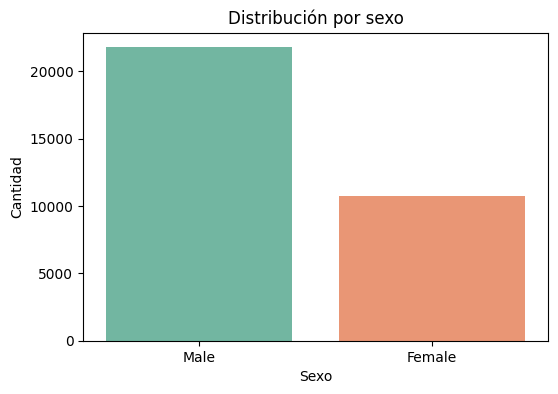

In [20]:
# ===============================================================
# DISTRIBUCIÓN DE SEX
# ===============================================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Sex",
    palette="Set2"
)

plt.title("Distribución por sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad")

plt.show()

C:\Users\Haand\AppData\Local\Temp\ipykernel_11344\4160157403.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


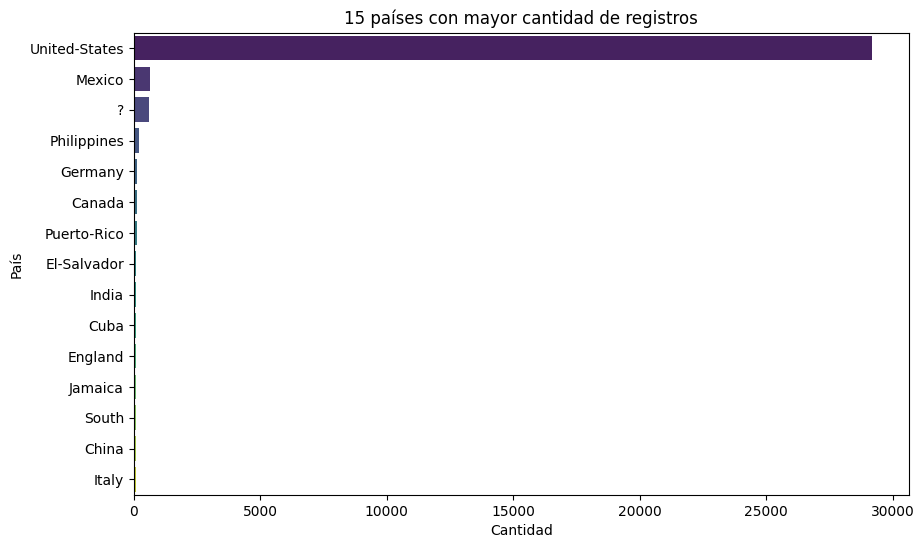

In [21]:
# ===============================================================
# DISTRIBUCIÓN DE NATIVE COUNTRY
# ===============================================================

top15 = df["Native_country"].value_counts().head(15).index

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="Native_country",
    order=top15,
    palette="viridis"
)

plt.title("15 países con mayor cantidad de registros")
plt.xlabel("Cantidad")
plt.ylabel("País")

plt.show()

Detección de Valores Atípicos (Outliers)

In [22]:
# ===============================================================
# FASE II - EDA
# BLOQUE 4.1
# DETECCIÓN DE OUTLIERS MEDIANTE IQR
# ===============================================================

variables_numericas = [
    "Age",
    "fnlwgt",
    "Education_num",
    "Capital_gain",
    "Capital_loss",
    "Hours_per_week"
]

resultado_outliers = []

for columna in variables_numericas:

    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    cantidad = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ].shape[0]

    porcentaje = (cantidad / len(df)) * 100

    resultado_outliers.append([
        columna,
        cantidad,
        round(porcentaje,2)
    ])

tabla_outliers = pd.DataFrame(
    resultado_outliers,
    columns=[
        "Variable",
        "Cantidad de Outliers",
        "Porcentaje (%)"
    ]
)

tabla_outliers

,Variable,Cantidad de Outliers,Porcentaje (%)
0,Age,143,0.44
1,fnlwgt,992,3.05
2,Education_num,1198,3.68
3,Capital_gain,2712,8.33
4,Capital_loss,1519,4.67
5,Hours_per_week,9008,27.66


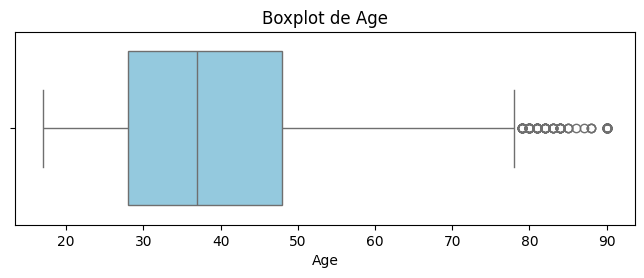

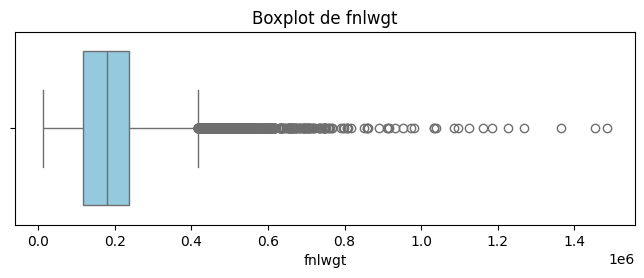

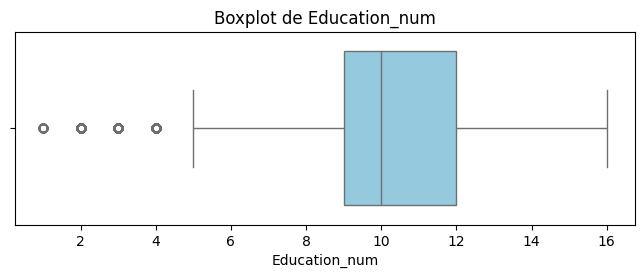

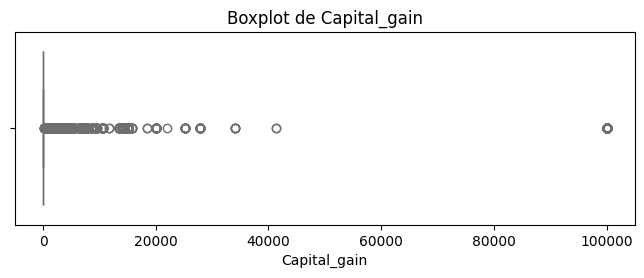

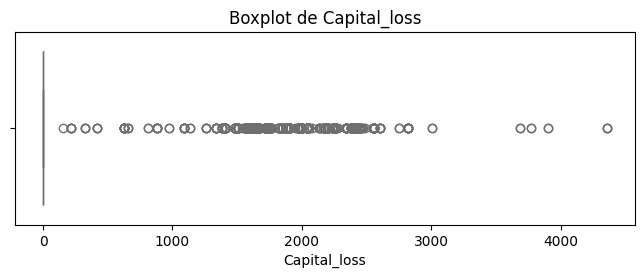

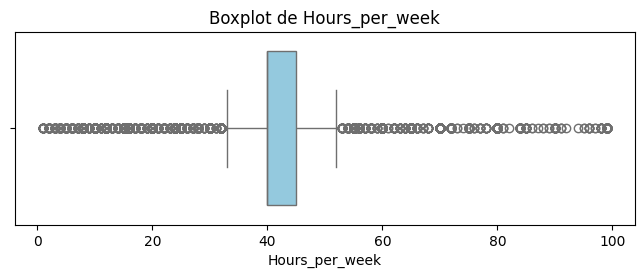

In [23]:
# ===============================================================
# BLOQUE 4.2
# BOXPLOTS
# ===============================================================

for variable in variables_numericas:

    plt.figure(figsize=(8,2.5))

    sns.boxplot(
        x=df[variable],
        color="skyblue"
    )

    plt.title(f"Boxplot de {variable}")

    plt.show()

Matriz de Correlación

In [24]:
# ===============================================================
# FASE II - EDA
# BLOQUE 5
# MATRIZ DE CORRELACIÓN
# ===============================================================

# Seleccionar únicamente variables numéricas

variables_numericas = df.select_dtypes(include=["int64","float64"])

# Calcular correlación

correlacion = variables_numericas.corr()

correlacion

,Age,fnlwgt,Education_num,Capital_gain,Capital_loss,Hours_per_week
Age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
Education_num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
Capital_gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
Capital_loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
Hours_per_week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


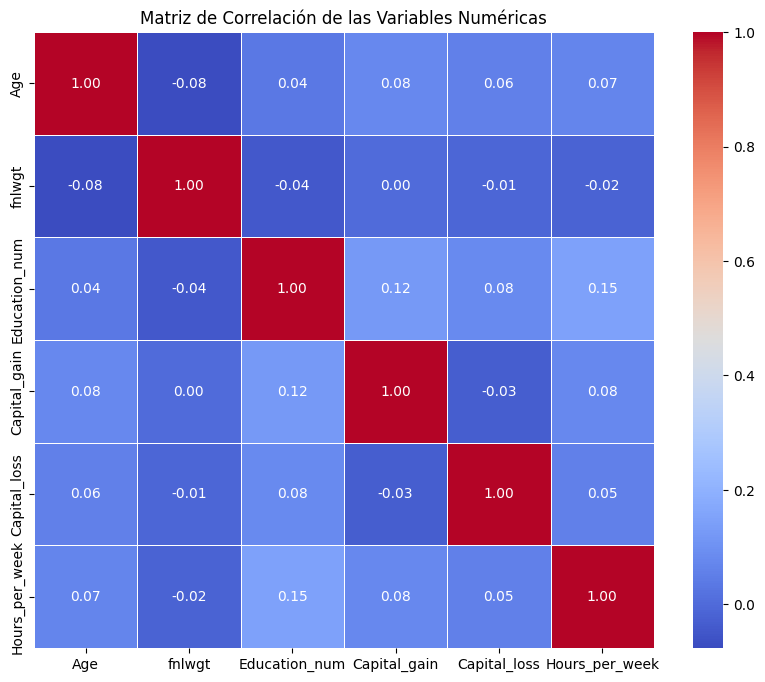

In [25]:
# ===============================================================
# HEATMAP DE CORRELACIÓN
# ===============================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Matriz de Correlación de las Variables Numéricas")

plt.show()

Relación entre las Variables y la Variable Objetivo (Income)

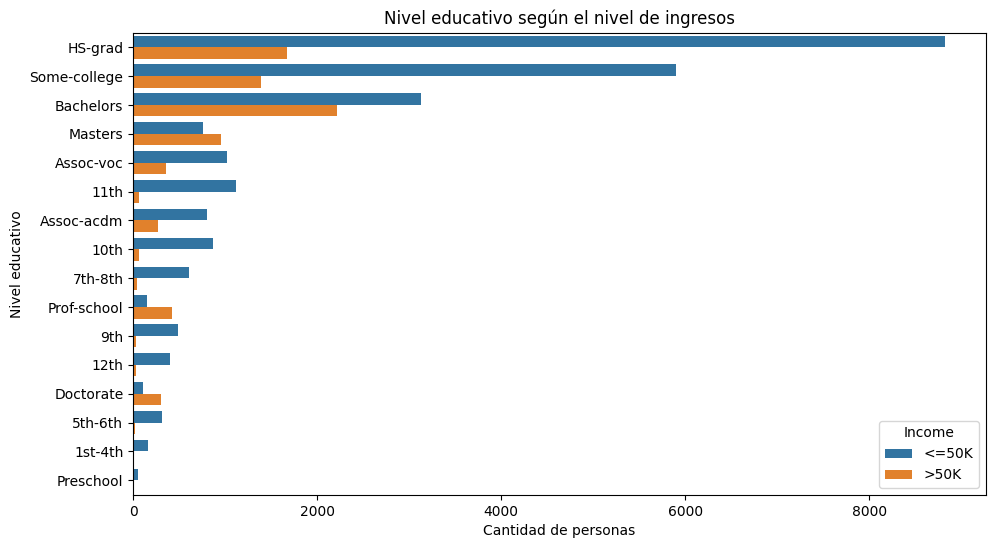

In [26]:
# ===============================================================
# BLOQUE 6.1
# EDUCATION VS INCOME
# ===============================================================

plt.figure(figsize=(11,6))

sns.countplot(
    data=df,
    y="Education",
    hue="Income",
    order=df["Education"].value_counts().index
)

plt.title("Nivel educativo según el nivel de ingresos")
plt.xlabel("Cantidad de personas")
plt.ylabel("Nivel educativo")

plt.legend(title="Income")

plt.show()

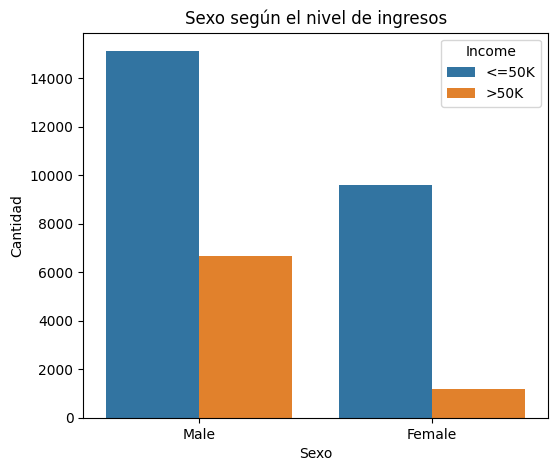

In [27]:
# ===============================================================
# BLOQUE 6.2
# SEX VS INCOME
# ===============================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Income"
)

plt.title("Sexo según el nivel de ingresos")
plt.xlabel("Sexo")
plt.ylabel("Cantidad")

plt.legend(title="Income")

plt.show()

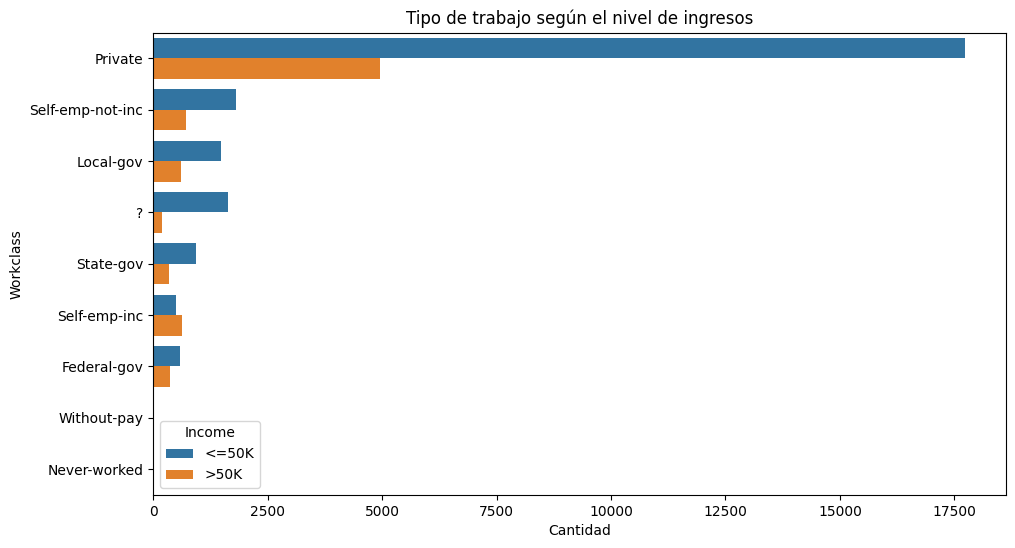

In [28]:
# ===============================================================
# BLOQUE 6.3
# WORKCLASS VS INCOME
# ===============================================================

plt.figure(figsize=(11,6))

sns.countplot(
    data=df,
    y="Workclass",
    hue="Income",
    order=df["Workclass"].value_counts().index
)

plt.title("Tipo de trabajo según el nivel de ingresos")
plt.xlabel("Cantidad")
plt.ylabel("Workclass")

plt.legend(title="Income")

plt.show()

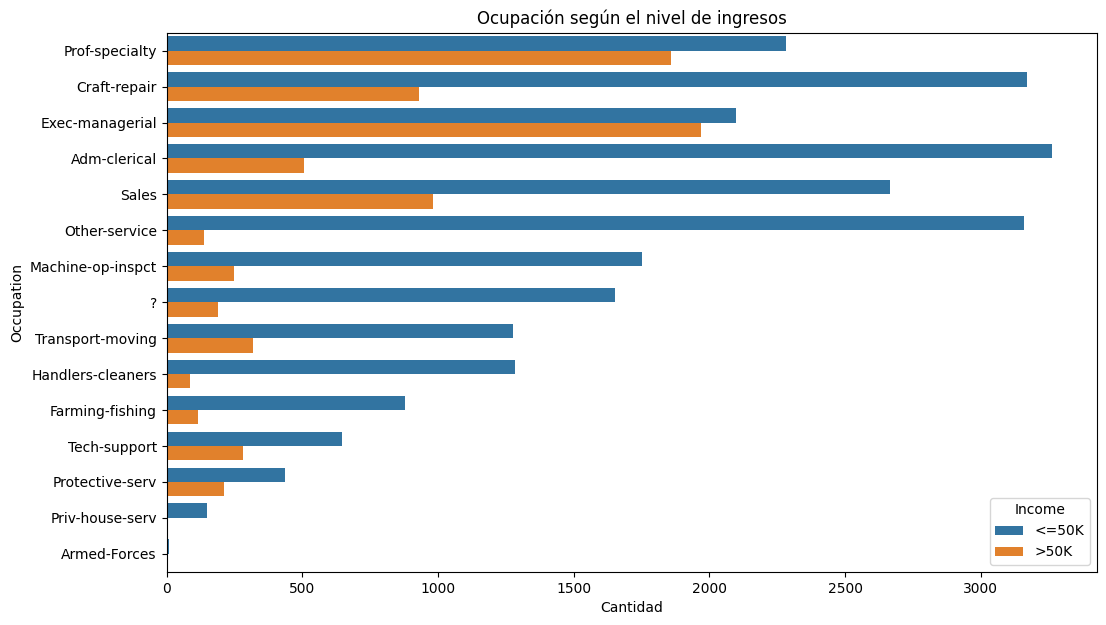

In [29]:
# ===============================================================
# BLOQUE 6.4
# OCCUPATION VS INCOME
# ===============================================================

plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y="Occupation",
    hue="Income",
    order=df["Occupation"].value_counts().index
)

plt.title("Ocupación según el nivel de ingresos")
plt.xlabel("Cantidad")
plt.ylabel("Occupation")

plt.legend(title="Income")

plt.show()

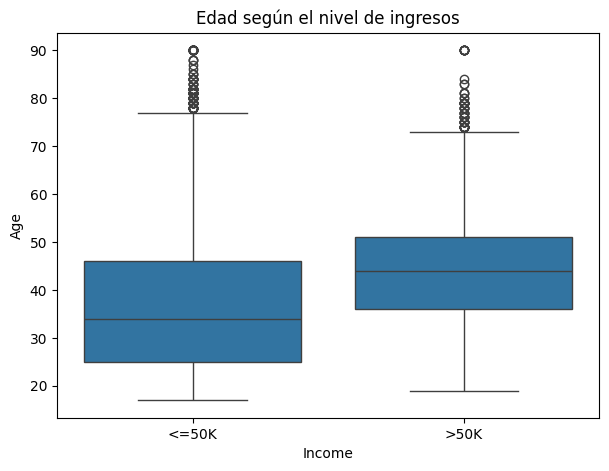

In [30]:
# ===============================================================
# BLOQUE 6.5
# AGE VS INCOME
# ===============================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Income",
    y="Age"
)

plt.title("Edad según el nivel de ingresos")

plt.show()

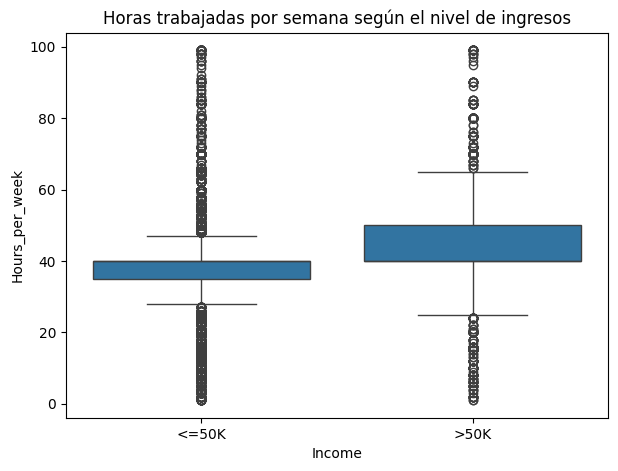

In [31]:
# ===============================================================
# BLOQUE 6.6
# HOURS PER WEEK VS INCOME
# ===============================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Income",
    y="Hours_per_week"
)

plt.title("Horas trabajadas por semana según el nivel de ingresos")

plt.show()

# FASE III. PREPROCESAMIENTO PARA LOS EXPERIMENTOS

En esta fase se prepara el conjunto de datos para el entrenamiento. Los símbolos `?`
se convierten en valores faltantes y los registros duplicados se eliminan antes de
realizar la división. La imputación, la codificación y la estandarización se ejecutan
dentro de un `Pipeline`, de modo que sus parámetros se calculen únicamente con los
datos de entrenamiento y se evite la fuga de información.

In [32]:
# ============================================================
# FASE III
# BLOQUE 1
# LIMPIEZA GENERAL DEL DATASET
# ============================================================

# Se crea una copia para conservar intacto el DataFrame original.
df_modelado = df.copy()

# Los símbolos "?" representan información faltante.
df_modelado.replace("?", np.nan, inplace=True)

registros_iniciales = df_modelado.shape[0]
duplicados_detectados = df_modelado.duplicated().sum()

# Los duplicados se eliminan antes de dividir los datos.
df_modelado.drop_duplicates(inplace=True)
df_modelado.reset_index(drop=True, inplace=True)

print("=" * 65)
print("RESUMEN DE LIMPIEZA")
print("=" * 65)
print(f"Registros iniciales       : {registros_iniciales}")
print(f"Duplicados eliminados     : {duplicados_detectados}")
print(f"Registros finales         : {df_modelado.shape[0]}")
print("\nValores faltantes pendientes:")
print(df_modelado.isna().sum()[df_modelado.isna().sum() > 0])

RESUMEN DE LIMPIEZA
Registros iniciales       : 32561
Duplicados eliminados     : 24
Registros finales         : 32537

Valores faltantes pendientes:
Workclass         1836
Occupation        1843
Native_country     582
dtype: int64


Los valores faltantes no se imputan directamente sobre todo el dataset. Su tratamiento
se realizará dentro del pipeline usando solamente los datos disponibles en cada
entrenamiento. Esta decisión evita que la moda o la mediana del conjunto de prueba
influyan en los modelos.

In [33]:
# ============================================================
# FASE III
# BLOQUE 2
# SEPARACIÓN DE PREDICTORES Y VARIABLE OBJETIVO
# ============================================================

X = df_modelado.drop(columns="Income")

y = df_modelado["Income"].map({
    "<=50K": 0,
    ">50K": 1
})

# Verificación de la codificación.
if y.isna().any():
    raise ValueError(
        "Se encontraron categorías no reconocidas en la variable Income."
    )

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("\nDistribución de la variable objetivo:")
print(y.value_counts().rename(index={0: "<=50K", 1: ">50K"}))

Dimensiones de X: (32537, 14)
Dimensiones de y: (32537,)

Distribución de la variable objetivo:
Income
<=50K    24698
>50K      7839
Name: count, dtype: int64


In [34]:
# ============================================================
# FASE III
# BLOQUE 3
# DIVISIÓN ESTRATIFICADA TRAIN / TEST
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

tabla_division = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Registros": [len(X_train), len(X_test)],
    "<=50K": [(y_train == 0).sum(), (y_test == 0).sum()],
    ">50K": [(y_train == 1).sum(), (y_test == 1).sum()],
    "% >50K": [
        round((y_train == 1).mean() * 100, 2),
        round((y_test == 1).mean() * 100, 2)
    ]
})

tabla_division

,Conjunto,Registros,<=50K,>50K,% >50K
0,Entrenamiento,26029,19758,6271,24.09
1,Prueba,6508,4940,1568,24.09


In [35]:
# ============================================================
# FASE III
# BLOQUE 4
# IDENTIFICACIÓN DE VARIABLES NUMÉRICAS Y CATEGÓRICAS
# ============================================================

variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:")
for variable in variables_numericas:
    print(" -", variable)

print("\nVariables categóricas:")
for variable in variables_categoricas:
    print(" -", variable)

Variables numéricas:
 - Age
 - fnlwgt
 - Education_num
 - Capital_gain
 - Capital_loss
 - Hours_per_week

Variables categóricas:
 - Workclass
 - Education
 - Marital_status
 - Occupation
 - Relationship
 - Race
 - Sex
 - Native_country


In [36]:
# ============================================================
# FASE III
# BLOQUE 5
# PIPELINE DE PREPROCESAMIENTO
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pipeline_numerico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalamiento", StandardScaler())
])

# Compatibilidad con versiones nuevas y anteriores de scikit-learn.
try:
    codificador = OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=False
    )
except TypeError:
    codificador = OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse=False
    )

pipeline_categorico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("onehot", codificador)
])

preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", pipeline_numerico, variables_numericas),
        ("categoricas", pipeline_categorico, variables_categoricas)
    ],
    remainder="drop"
)

print("Pipeline de preprocesamiento creado correctamente.")
print("La imputación y el escalamiento se ajustarán solo con entrenamiento.")

Pipeline de preprocesamiento creado correctamente.
La imputación y el escalamiento se ajustarán solo con entrenamiento.


# FASE IV. EXPERIMENTO 1: DATASET ORIGINAL

En el primer experimento se entrenan cinco algoritmos sin aplicar técnicas de balanceo
ni búsqueda de hiperparámetros. Se mantienen los valores predeterminados de cada
algoritmo, salvo configuraciones técnicas necesarias para reproducibilidad o
convergencia. Todos los modelos reciben la misma partición de entrenamiento y prueba.

In [37]:
# ============================================================
# FASE IV
# BLOQUE 1
# LIBRERÍAS DE MODELADO Y EVALUACIÓN
# ============================================================

import time
import warnings

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    make_scorer
)

warnings.filterwarnings("ignore", category=UserWarning)

print("Librerías para el Experimento 1 cargadas correctamente.")

Librerías para el Experimento 1 cargadas correctamente.


In [38]:
# ============================================================
# FASE IV
# BLOQUE 2
# MODELOS CON CONFIGURACIÓN BASE
# ============================================================

modelos_experimento_1 = {
    "Regresión Logística": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    "Árbol de Decisión": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

print("Modelos del Experimento 1:")
for nombre in modelos_experimento_1:
    print(" -", nombre)

Modelos del Experimento 1:
 - Regresión Logística
 - Árbol de Decisión
 - Random Forest
 - KNN
 - SVM


`max_iter=2000` se utiliza en Regresión Logística únicamente para permitir la
convergencia del proceso de optimización. `random_state=42` asegura que los resultados
sean reproducibles y `n_jobs=-1` aprovecha los núcleos disponibles, sin modificar el
criterio predictivo del modelo.

In [39]:
# ============================================================
# FASE IV
# BLOQUE 3
# CONFIGURACIÓN DE LA VALIDACIÓN CRUZADA
# ============================================================

validacion_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas_cv = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        pos_label=1,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        pos_label=1,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        pos_label=1,
        zero_division=0
    ),
    "mcc": make_scorer(matthews_corrcoef)
}

print("Validación cruzada estratificada de 5 particiones configurada.")

Validación cruzada estratificada de 5 particiones configurada.


In [40]:
# ============================================================
# FASE IV
# BLOQUE 4
# FUNCIÓN GENERAL DE EVALUACIÓN
# ============================================================

def evaluar_modelo_experimento_1(nombre, estimador):
    """
    Entrena un modelo mediante un Pipeline, calcula métricas sobre
    el conjunto de prueba y realiza validación cruzada estratificada.

    La clase positiva corresponde a >50K, codificada con el valor 1.
    """

    print("\n" + "=" * 75)
    print(f"MODELO: {nombre}")
    print("=" * 75)

    pipeline_modelo = Pipeline(steps=[
        ("preprocesamiento", clone(preprocesador)),
        ("modelo", clone(estimador))
    ])

    inicio = time.time()

    # Entrenamiento con el conjunto original, sin balanceo.
    pipeline_modelo.fit(X_train, y_train)

    # Predicción exclusivamente sobre el conjunto de prueba.
    y_pred = pipeline_modelo.predict(X_test)

    # Métricas de prueba.
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, pos_label=1, zero_division=0
    )
    recall = recall_score(
        y_test, y_pred, pos_label=1, zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred, pos_label=1, zero_division=0
    )
    mcc = matthews_corrcoef(y_test, y_pred)

    # El pipeline completo se vuelve a ajustar dentro de cada fold.
    resultados_cv = cross_validate(
        pipeline_modelo,
        X_train,
        y_train,
        cv=validacion_cruzada,
        scoring=metricas_cv,
        n_jobs=-1,
        return_train_score=False
    )

    duracion = time.time() - inicio
    matriz = confusion_matrix(y_test, y_pred)

    print(f"Accuracy de prueba          : {accuracy:.4f}")
    print(f"Precision clase >50K        : {precision:.4f}")
    print(f"Recall clase >50K           : {recall:.4f}")
    print(f"F1-score clase >50K         : {f1:.4f}")
    print(f"MCC                         : {mcc:.4f}")
    print(f"CV Accuracy                 : {resultados_cv['test_accuracy'].mean():.4f}")
    print(f"CV F1 clase >50K            : {resultados_cv['test_f1'].mean():.4f}")
    print(f"CV MCC                      : {resultados_cv['test_mcc'].mean():.4f}")
    print(f"Tiempo total                : {duracion:.2f} segundos")

    print("\nReporte de clasificación:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["<=50K", ">50K"],
        digits=4,
        zero_division=0
    ))

    resultado = {
        "Experimento": "E1 - Original",
        "Modelo": nombre,
        "Accuracy": accuracy,
        "Precision_>50K": precision,
        "Recall_>50K": recall,
        "F1_>50K": f1,
        "MCC": mcc,
        "CV_Accuracy_Media": resultados_cv["test_accuracy"].mean(),
        "CV_Accuracy_Desv": resultados_cv["test_accuracy"].std(),
        "CV_Precision_Media": resultados_cv["test_precision"].mean(),
        "CV_Recall_Media": resultados_cv["test_recall"].mean(),
        "CV_F1_Media": resultados_cv["test_f1"].mean(),
        "CV_F1_Desv": resultados_cv["test_f1"].std(),
        "CV_MCC_Media": resultados_cv["test_mcc"].mean(),
        "CV_MCC_Desv": resultados_cv["test_mcc"].std(),
        "Tiempo_segundos": duracion
    }

    return resultado, pipeline_modelo, matriz, y_pred

In [41]:
# ============================================================
# FASE IV
# BLOQUE 5
# ENTRENAMIENTO DE LOS CINCO MODELOS
# ============================================================

resultados_experimento_1 = []
pipelines_experimento_1 = {}
matrices_experimento_1 = {}
predicciones_experimento_1 = {}

for nombre, modelo in modelos_experimento_1.items():

    resultado, pipeline_entrenado, matriz, prediccion = (
        evaluar_modelo_experimento_1(nombre, modelo)
    )

    resultados_experimento_1.append(resultado)
    pipelines_experimento_1[nombre] = pipeline_entrenado
    matrices_experimento_1[nombre] = matriz
    predicciones_experimento_1[nombre] = prediccion

print("\nLos cinco modelos del Experimento 1 fueron evaluados.")


MODELO: Regresión Logística
Accuracy de prueba          : 0.8571
Precision clase >50K        : 0.7443
Recall clase >50K           : 0.6199
F1-score clase >50K         : 0.6764
MCC                         : 0.5897
CV Accuracy                 : 0.8493
CV F1 clase >50K            : 0.6538
CV MCC                      : 0.5641
Tiempo total                : 15.61 segundos

Reporte de clasificación:
              precision    recall  f1-score   support

       <=50K     0.8854    0.9324    0.9083      4940
        >50K     0.7443    0.6199    0.6764      1568

    accuracy                         0.8571      6508
   macro avg     0.8148    0.7761    0.7924      6508
weighted avg     0.8514    0.8571    0.8524      6508


MODELO: Árbol de Decisión
Accuracy de prueba          : 0.8178
Precision clase >50K        : 0.6212
Recall clase >50K           : 0.6244
F1-score clase >50K         : 0.6228
MCC                         : 0.5026
CV Accuracy                 : 0.8111
CV F1 clase >50K           

# FASE V. RESULTADOS DEL EXPERIMENTO 1

La comparación se ordena principalmente por MCC y F1-score de la clase `>50K`.
Esta decisión evita seleccionar el mejor modelo únicamente por Accuracy, una métrica
que puede favorecer a la clase mayoritaria cuando existe desbalance.

In [42]:
# ============================================================
# FASE V
# BLOQUE 1
# TABLA COMPARATIVA DEL EXPERIMENTO 1
# ============================================================

tabla_experimento_1 = pd.DataFrame(resultados_experimento_1)

tabla_experimento_1 = tabla_experimento_1.sort_values(
    by=["MCC", "F1_>50K", "Recall_>50K", "Accuracy"],
    ascending=False
).reset_index(drop=True)

columnas_principales = [
    "Modelo",
    "Accuracy",
    "Precision_>50K",
    "Recall_>50K",
    "F1_>50K",
    "MCC",
    "CV_Accuracy_Media",
    "CV_F1_Media",
    "CV_MCC_Media"
]

tabla_experimento_1[columnas_principales].round(4)

,Modelo,Accuracy,Precision_>50K,Recall_>50K,F1_>50K,MCC,CV_Accuracy_Media,CV_F1_Media,CV_MCC_Media
0,Random Forest,0.8603,0.7464,0.6365,0.6871,0.6011,0.8517,0.6667,0.5755
1,SVM,0.8589,0.7673,0.5950,0.6703,0.5900,0.8549,0.6566,0.5761
2,Regresión Logística,0.8571,0.7443,0.6199,0.6764,0.5897,0.8493,0.6538,0.5641
3,KNN,0.8360,0.6722,0.6237,0.6470,0.5411,0.8310,0.6331,0.5246
4,Árbol de Decisión,0.8178,0.6212,0.6244,0.6228,0.5026,0.8111,0.6165,0.4916


In [43]:
# ============================================================
# FASE V
# BLOQUE 2
# IDENTIFICACIÓN DEL MEJOR MODELO DEL EXPERIMENTO 1
# ============================================================

mejor_experimento_1 = tabla_experimento_1.iloc[0]

print("=" * 70)
print("MEJOR MODELO DEL EXPERIMENTO 1")
print("=" * 70)
print(f"Modelo                   : {mejor_experimento_1['Modelo']}")
print(f"Accuracy                 : {mejor_experimento_1['Accuracy']:.4f}")
print(f"Precision de >50K        : {mejor_experimento_1['Precision_>50K']:.4f}")
print(f"Recall de >50K           : {mejor_experimento_1['Recall_>50K']:.4f}")
print(f"F1-score de >50K         : {mejor_experimento_1['F1_>50K']:.4f}")
print(f"MCC                      : {mejor_experimento_1['MCC']:.4f}")
print(f"CV F1 media              : {mejor_experimento_1['CV_F1_Media']:.4f}")
print(f"CV MCC media             : {mejor_experimento_1['CV_MCC_Media']:.4f}")

MEJOR MODELO DEL EXPERIMENTO 1
Modelo                   : Random Forest
Accuracy                 : 0.8603
Precision de >50K        : 0.7464
Recall de >50K           : 0.6365
F1-score de >50K         : 0.6871
MCC                      : 0.6011
CV F1 media              : 0.6667
CV MCC media             : 0.5755


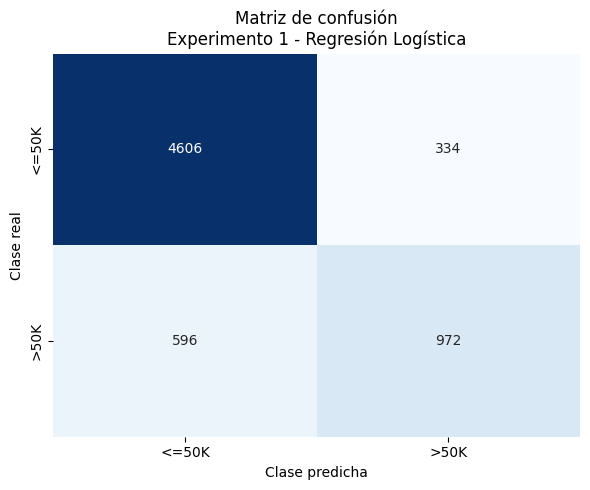

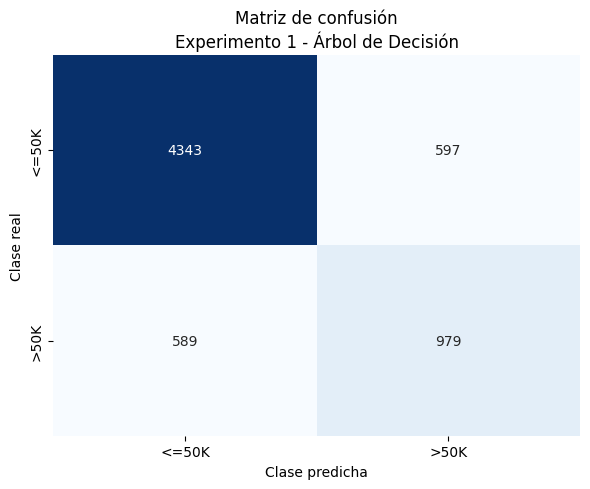

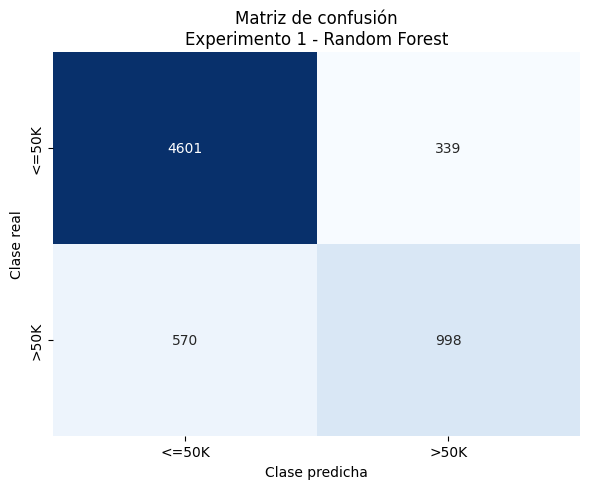

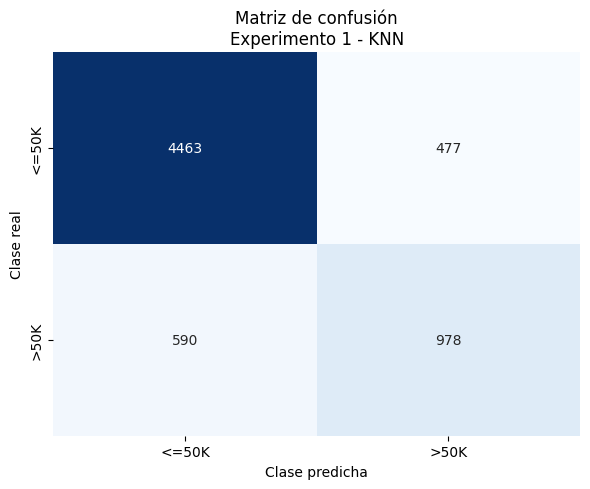

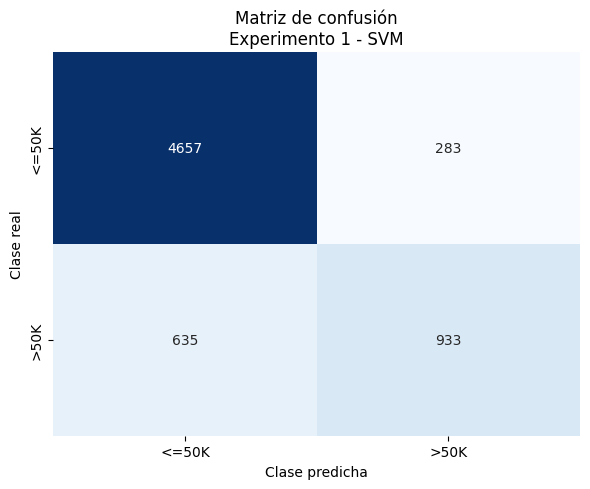

In [44]:
# ============================================================
# FASE V
# BLOQUE 3
# MATRICES DE CONFUSIÓN
# ============================================================

for nombre, matriz in matrices_experimento_1.items():

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"]
    )

    plt.title(
        f"Matriz de confusión\nExperimento 1 - {nombre}"
    )
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.show()

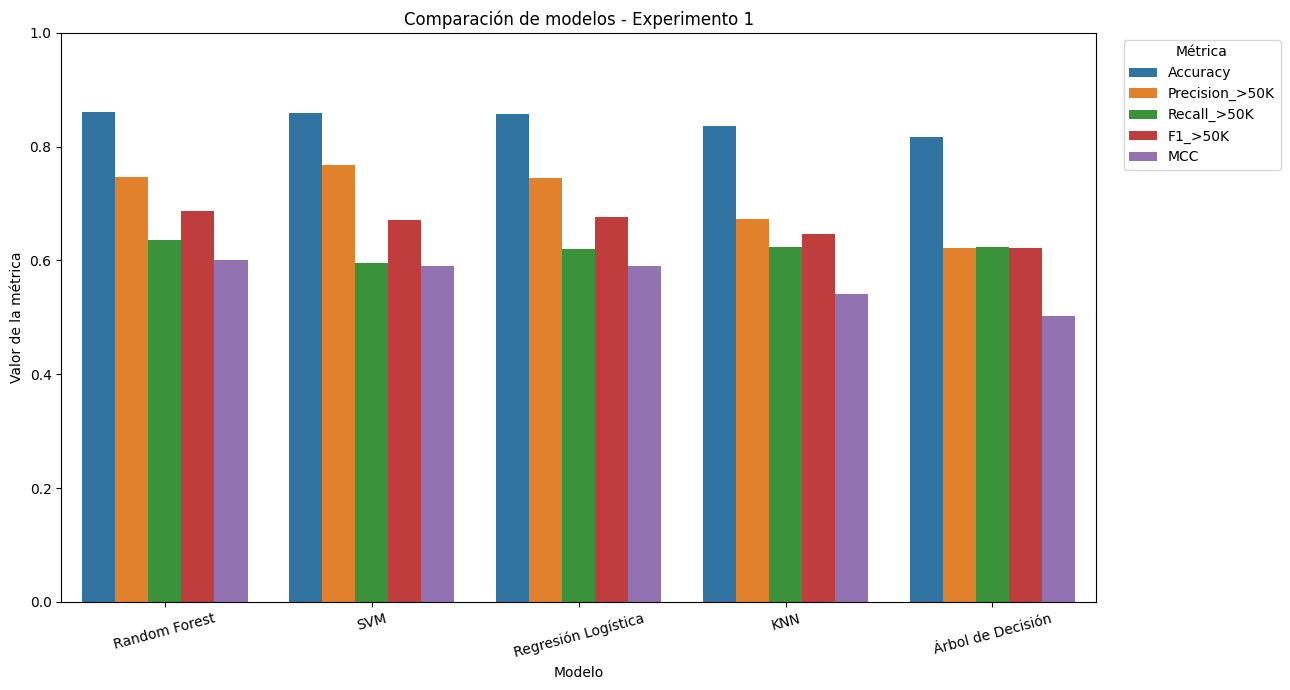

In [45]:
# ============================================================
# FASE V
# BLOQUE 4
# GRÁFICO COMPARATIVO DE MÉTRICAS
# ============================================================

metricas_grafico = [
    "Accuracy",
    "Precision_>50K",
    "Recall_>50K",
    "F1_>50K",
    "MCC"
]

tabla_grafico = tabla_experimento_1.melt(
    id_vars="Modelo",
    value_vars=metricas_grafico,
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=tabla_grafico,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.ylim(0, 1)
plt.title("Comparación de modelos - Experimento 1")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=15)
plt.legend(title="Métrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# FASE V
# BLOQUE 5
# EXPORTACIÓN DE RESULTADOS
# ============================================================

archivo_resultados_e1 = "resultados_experimento_1.csv"

tabla_experimento_1.to_csv(
    archivo_resultados_e1,
    index=False,
    encoding="utf-8-sig"
)

print(f"Resultados exportados en: {archivo_resultados_e1}")

Resultados exportados en: resultados_experimento_1.csv


## Criterio para interpretar el Experimento 1

La interpretación definitiva debe redactarse después de ejecutar todas las celdas.
No se deben copiar los valores antiguos del artículo, porque las métricas anteriores
se calcularon con promedio ponderado y el Árbol de Decisión utilizaba una profundidad
configurada manualmente. En esta versión, `Precision`, `Recall` y `F1-score` representan
directamente el desempeño sobre la clase minoritaria `>50K`.

El siguiente bloque experimental aplicará SMOTE únicamente dentro del conjunto de
entrenamiento y mantendrá intacto el conjunto de prueba.

# FASE IV. EXPERIMENTO 2: BALANCEO MEDIANTE SMOTE

En este experimento se vuelven a entrenar los cinco algoritmos utilizando SMOTE
para aumentar la representación de la clase minoritaria `>50K`.

SMOTE se incorpora dentro de un pipeline para que los registros sintéticos se
generen exclusivamente con los datos de entrenamiento. El conjunto de prueba
permanece intacto y conserva su distribución real.

In [47]:
# ============================================================
# EXPERIMENTO 2
# BLOQUE 1: LIBRERÍAS Y VERIFICACIÓN
# ============================================================

# ¿QUÉ SE HACE?
# Se importan SMOTE y el pipeline de imbalanced-learn.

# ¿PARA QUÉ SE HACE?
# Para balancear la clase >50K solamente durante el entrenamiento
# y evitar fuga de información hacia el conjunto de prueba.

import sys
import subprocess
import time
import warnings
from collections import Counter

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "imbalanced-learn"
    ])
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.base import clone
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

variables_requeridas = [
    "X_train", "X_test", "y_train", "y_test",
    "preprocesador", "modelos_experimento_1",
    "validacion_cruzada", "metricas_cv",
    "tabla_experimento_1"
]

faltantes = [
    variable for variable in variables_requeridas
    if variable not in globals()
]

if faltantes:
    raise NameError(
        "Faltan variables de las fases anteriores: "
        + ", ".join(faltantes)
    )

warnings.filterwarnings("ignore", category=UserWarning)

print("Entorno del Experimento 2 preparado correctamente.")

Entorno del Experimento 2 preparado correctamente.


In [48]:
# ============================================================
# EXPERIMENTO 2
# BLOQUE 2: COMPROBACIÓN DEL BALANCEO
# ============================================================

# ¿QUÉ SE HACE?
# Se aplica temporalmente el preprocesamiento y SMOTE para mostrar
# la distribución de clases antes y después del balanceo.

# ¿PARA QUÉ SE HACE?
# Para dejar evidencia experimental de que la clase minoritaria
# alcanza la misma cantidad de registros que la clase mayoritaria.

preprocesador_verificacion = clone(preprocesador)

X_train_preparado = preprocesador_verificacion.fit_transform(
    X_train,
    y_train
)

smote_verificacion = SMOTE(random_state=42)

X_train_smote_verificacion, y_train_smote_verificacion = (
    smote_verificacion.fit_resample(
        X_train_preparado,
        y_train
    )
)

antes = Counter(y_train)
despues = Counter(y_train_smote_verificacion)

tabla_balanceo_smote = pd.DataFrame({
    "Clase": ["<=50K", ">50K"],
    "Antes de SMOTE": [antes[0], antes[1]],
    "Después de SMOTE": [despues[0], despues[1]]
})

display(tabla_balanceo_smote)

del X_train_preparado
del X_train_smote_verificacion
del y_train_smote_verificacion
del preprocesador_verificacion
del smote_verificacion

,Clase,Antes de SMOTE,Después de SMOTE
0,<=50K,19758,19758
1,>50K,6271,19758


In [49]:
# ============================================================
# EXPERIMENTO 2
# BLOQUE 3: MODELOS CON LA MISMA CONFIGURACIÓN BASE
# ============================================================

# ¿QUÉ SE HACE?
# Se crean copias de los cinco modelos del Experimento 1.

# ¿PARA QUÉ SE HACE?
# Para que la única diferencia entre E1 y E2 sea el uso de SMOTE.

modelos_experimento_2 = {
    nombre: clone(modelo)
    for nombre, modelo in modelos_experimento_1.items()
}

print("Modelos preparados:")
for nombre in modelos_experimento_2:
    print(" -", nombre)

Modelos preparados:
 - Regresión Logística
 - Árbol de Decisión
 - Random Forest
 - KNN
 - SVM


In [50]:
# ============================================================
# EXPERIMENTO 2
# BLOQUE 4: FUNCIÓN DE EVALUACIÓN CON SMOTE
# ============================================================

def evaluar_modelo_experimento_2(nombre, estimador):
    """
    Entrena un modelo con preprocesamiento y SMOTE dentro del
    pipeline. Evalúa la clase positiva >50K sobre X_test original.
    """

    print("\n" + "=" * 78)
    print(f"MODELO CON SMOTE: {nombre}")
    print("=" * 78)

    pipeline_modelo = ImbPipeline(steps=[
        ("preprocesamiento", clone(preprocesador)),
        ("smote", SMOTE(random_state=42)),
        ("modelo", clone(estimador))
    ])

    inicio = time.time()

    pipeline_modelo.fit(X_train, y_train)
    y_pred = pipeline_modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, pos_label=1, zero_division=0
    )
    recall = recall_score(
        y_test, y_pred, pos_label=1, zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred, pos_label=1, zero_division=0
    )
    mcc = matthews_corrcoef(y_test, y_pred)

    # SMOTE se vuelve a aplicar solamente en el entrenamiento
    # interno de cada fold.
    resultados_cv = cross_validate(
        pipeline_modelo,
        X_train,
        y_train,
        cv=validacion_cruzada,
        scoring=metricas_cv,
        n_jobs=1,
        return_train_score=False
    )

    tiempo = time.time() - inicio
    matriz = confusion_matrix(y_test, y_pred)

    print(f"Accuracy                     : {accuracy:.4f}")
    print(f"Precision clase >50K         : {precision:.4f}")
    print(f"Recall clase >50K            : {recall:.4f}")
    print(f"F1-score clase >50K          : {f1:.4f}")
    print(f"MCC                          : {mcc:.4f}")
    print(f"CV F1                        : {resultados_cv['test_f1'].mean():.4f}")
    print(f"CV MCC                       : {resultados_cv['test_mcc'].mean():.4f}")
    print(f"Tiempo                       : {tiempo:.2f} segundos")

    print("\nReporte de clasificación:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["<=50K", ">50K"],
        digits=4,
        zero_division=0
    ))

    resultado = {
        "Experimento": "E2 - SMOTE",
        "Modelo": nombre,
        "Accuracy": accuracy,
        "Precision_>50K": precision,
        "Recall_>50K": recall,
        "F1_>50K": f1,
        "MCC": mcc,
        "CV_Accuracy_Media": resultados_cv["test_accuracy"].mean(),
        "CV_Accuracy_Desv": resultados_cv["test_accuracy"].std(),
        "CV_Precision_Media": resultados_cv["test_precision"].mean(),
        "CV_Recall_Media": resultados_cv["test_recall"].mean(),
        "CV_F1_Media": resultados_cv["test_f1"].mean(),
        "CV_F1_Desv": resultados_cv["test_f1"].std(),
        "CV_MCC_Media": resultados_cv["test_mcc"].mean(),
        "CV_MCC_Desv": resultados_cv["test_mcc"].std(),
        "Tiempo_segundos": tiempo
    }

    return resultado, pipeline_modelo, matriz, y_pred

In [51]:
# ============================================================
# EXPERIMENTO 2
# BLOQUE 5: ENTRENAMIENTO DE LOS CINCO MODELOS
# ============================================================

resultados_experimento_2 = []
pipelines_experimento_2 = {}
matrices_experimento_2 = {}
predicciones_experimento_2 = {}

for nombre, modelo in modelos_experimento_2.items():

    resultado, pipeline, matriz, prediccion = (
        evaluar_modelo_experimento_2(nombre, modelo)
    )

    resultados_experimento_2.append(resultado)
    pipelines_experimento_2[nombre] = pipeline
    matrices_experimento_2[nombre] = matriz
    predicciones_experimento_2[nombre] = prediccion

print("\nExperimento 2 finalizado correctamente.")


MODELO CON SMOTE: Regresión Logística
Accuracy                     : 0.8107
Precision clase >50K         : 0.5716
Recall clase >50K            : 0.8559
F1-score clase >50K          : 0.6854
MCC                          : 0.5808
CV F1                        : 0.6786
CV MCC                       : 0.5703
Tiempo                       : 9.69 segundos

Reporte de clasificación:
              precision    recall  f1-score   support

       <=50K     0.9457    0.7964    0.8646      4940
        >50K     0.5716    0.8559    0.6854      1568

    accuracy                         0.8107      6508
   macro avg     0.7586    0.8261    0.7750      6508
weighted avg     0.8555    0.8107    0.8214      6508


MODELO CON SMOTE: Árbol de Decisión
Accuracy                     : 0.8122
Precision clase >50K         : 0.5997
Recall clase >50K            : 0.6639
F1-score clase >50K          : 0.6301
MCC                          : 0.5059
CV F1                        : 0.6151
CV MCC                       : 

In [52]:
# ============================================================
# EXPERIMENTO 2
# BLOQUE 6: TABLA Y COMPARACIÓN CON E1
# ============================================================

tabla_experimento_2 = pd.DataFrame(
    resultados_experimento_2
).sort_values(
    by=["MCC", "F1_>50K", "Recall_>50K", "Accuracy"],
    ascending=False
).reset_index(drop=True)

columnas_principales_e2 = [
    "Modelo", "Accuracy", "Precision_>50K",
    "Recall_>50K", "F1_>50K", "MCC",
    "CV_Accuracy_Media", "CV_F1_Media", "CV_MCC_Media"
]

display(tabla_experimento_2[columnas_principales_e2].round(4))

metricas_comparacion = [
    "Accuracy", "Precision_>50K", "Recall_>50K",
    "F1_>50K", "MCC", "CV_Accuracy_Media",
    "CV_F1_Media", "CV_MCC_Media"
]

tabla_comparacion_e1_e2 = tabla_experimento_1[
    ["Modelo"] + metricas_comparacion
].merge(
    tabla_experimento_2[["Modelo"] + metricas_comparacion],
    on="Modelo",
    suffixes=("_E1", "_E2")
)

for metrica in metricas_comparacion:
    tabla_comparacion_e1_e2[f"Diferencia_{metrica}"] = (
        tabla_comparacion_e1_e2[f"{metrica}_E2"]
        - tabla_comparacion_e1_e2[f"{metrica}_E1"]
    )

display(tabla_comparacion_e1_e2.round(4))

,Modelo,Accuracy,Precision_>50K,Recall_>50K,F1_>50K,MCC,CV_Accuracy_Media,CV_F1_Media,CV_MCC_Media
0,Random Forest,0.8519,0.6817,0.7226,0.7015,0.6036,0.8433,0.6786,0.5751
1,SVM,0.8199,0.5856,0.8635,0.6979,0.5983,0.8143,0.6869,0.5819
2,Regresión Logística,0.8107,0.5716,0.8559,0.6854,0.5808,0.8079,0.6786,0.5703
3,KNN,0.7806,0.5296,0.7997,0.6372,0.5104,0.7829,0.6390,0.5128
4,Árbol de Decisión,0.8122,0.5997,0.6639,0.6301,0.5059,0.8034,0.6151,0.4852


,Modelo,Accuracy_E1,Precision_>50K_E1,Recall_>50K_E1,F1_>50K_E1,MCC_E1,CV_Accuracy_Media_E1,CV_F1_Media_E1,CV_MCC_Media_E1,Accuracy_E2,...,CV_F1_Media_E2,CV_MCC_Media_E2,Diferencia_Accuracy,Diferencia_Precision_>50K,Diferencia_Recall_>50K,Diferencia_F1_>50K,Diferencia_MCC,Diferencia_CV_Accuracy_Media,Diferencia_CV_F1_Media,Diferencia_CV_MCC_Media
0,Random Forest,0.8603,0.7464,0.6365,0.6871,0.6011,0.8517,0.6667,0.5755,0.8519,...,0.6786,0.5751,-0.0085,-0.0647,0.0861,0.0145,0.0025,-0.0085,0.0119,-0.0004
1,SVM,0.8589,0.7673,0.5950,0.6703,0.5900,0.8549,0.6566,0.5761,0.8199,...,0.6869,0.5819,-0.0390,-0.1816,0.2685,0.0277,0.0084,-0.0406,0.0303,0.0058
2,Regresión Logística,0.8571,0.7443,0.6199,0.6764,0.5897,0.8493,0.6538,0.5641,0.8107,...,0.6786,0.5703,-0.0464,-0.1727,0.2360,0.0090,-0.0089,-0.0414,0.0247,0.0062
3,KNN,0.8360,0.6722,0.6237,0.6470,0.5411,0.8310,0.6331,0.5246,0.7806,...,0.6390,0.5128,-0.0555,-0.1426,0.1760,-0.0098,-0.0307,-0.0480,0.0058,-0.0119
4,Árbol de Decisión,0.8178,0.6212,0.6244,0.6228,0.5026,0.8111,0.6165,0.4916,0.8122,...,0.6151,0.4852,-0.0055,-0.0215,0.0395,0.0074,0.0033,-0.0077,-0.0013,-0.0064


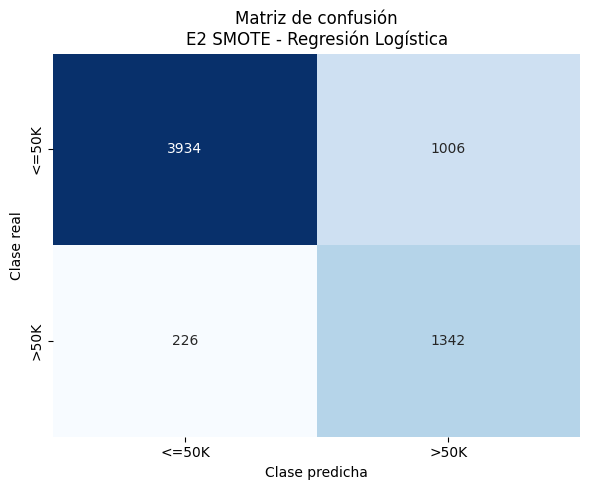

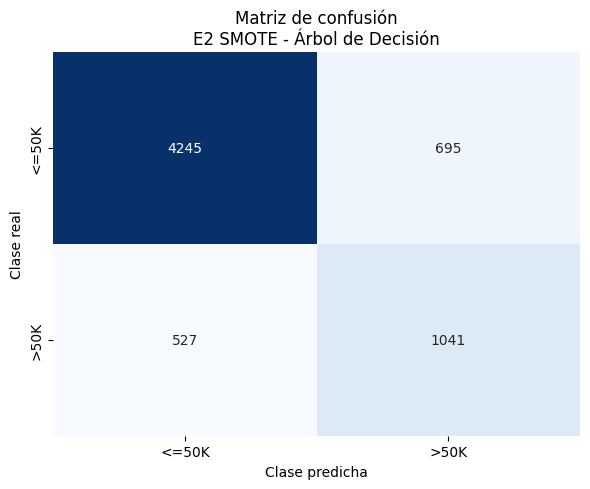

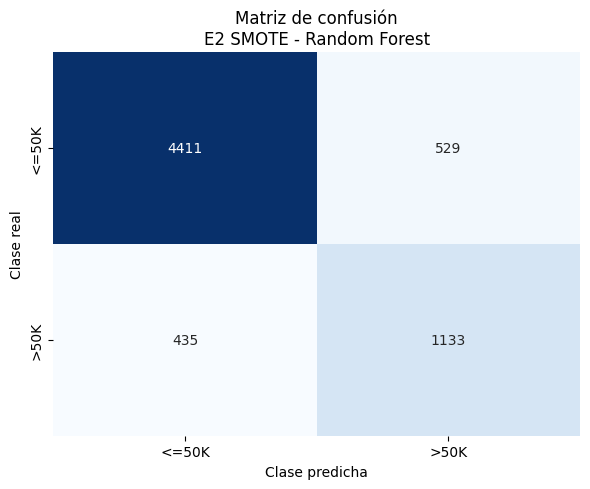

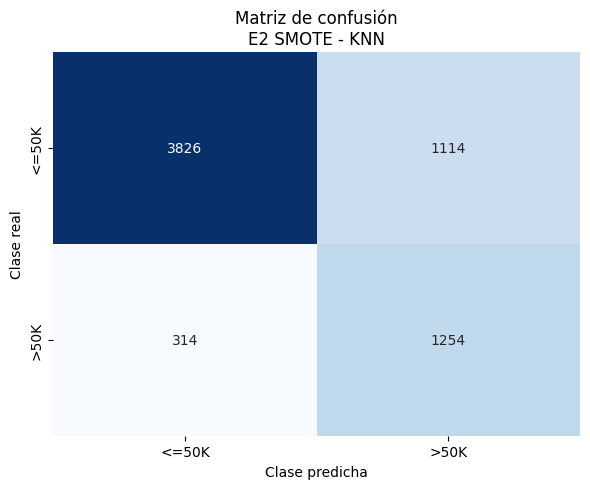

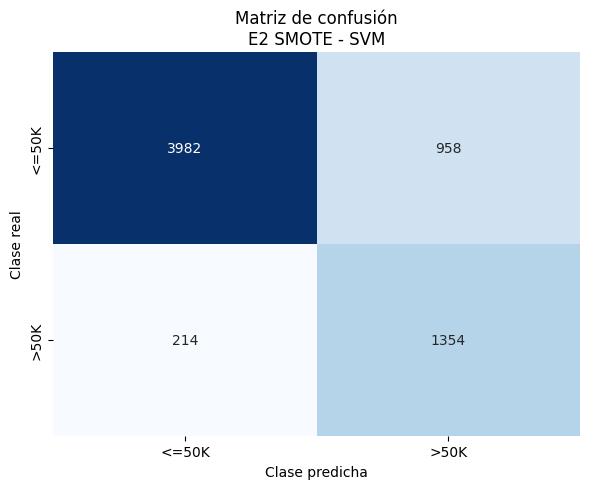

Resultados del Experimento 2 exportados.


In [53]:
# ============================================================
# EXPERIMENTO 2
# BLOQUE 7: MATRICES Y EXPORTACIÓN
# ============================================================

for nombre, matriz in matrices_experimento_2.items():

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"]
    )

    plt.title(f"Matriz de confusión\nE2 SMOTE - {nombre}")
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.show()

tabla_experimento_2.to_csv(
    "resultados_experimento_2_smote.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_comparacion_e1_e2.to_csv(
    "comparacion_experimento_1_vs_2.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_balanceo_smote.to_csv(
    "distribucion_clases_smote.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Resultados del Experimento 2 exportados.")

## Interpretación del Experimento 2

SMOTE busca mejorar la detección de la clase minoritaria `>50K`. La evaluación
debe considerar que un aumento del Recall puede estar acompañado por una
disminución de Precision o Accuracy. Por esta razón, el efecto del balanceo se
analiza conjuntamente mediante F1-score, MCC, validación cruzada y matrices de
confusión.

# FASE IV. EXPERIMENTO 3: SMOTE + GRIDSEARCHCV

El tercer experimento optimiza los hiperparámetros de los cinco modelos mediante
GridSearchCV. Para reducir el tiempo de ejecución se comparan dos configuraciones
representativas por algoritmo, manteniendo SMOTE dentro del pipeline y validación
cruzada estratificada de cinco particiones.

La mejor configuración se seleccionará mediante MCC.

# FASE IV. EXPERIMENTO 3: SMOTE + GRIDSEARCHCV

En este experimento se optimizan los hiperparámetros de los cinco algoritmos
utilizando GridSearchCV. El preprocesamiento y SMOTE se mantienen dentro del
pipeline para evitar fuga de información.

La búsqueda se ejecutará secuencialmente, utilizando un solo proceso, para evitar
errores de memoria. Cada algoritmo evaluará dos configuraciones mediante validación
cruzada estratificada de cinco particiones.

La mejor configuración será seleccionada utilizando el coeficiente MCC.

In [54]:
# ============================================================
# EXPERIMENTO 3
# BLOQUE 1: LIBRERÍAS, MEMORIA Y VERIFICACIÓN
# ============================================================

# ¿QUÉ SE HACE?
# Se importan las herramientas necesarias y se limita el uso
# del procesador a un solo hilo.

# ¿PARA QUÉ SE HACE?
# Para evitar el TerminatedWorkerError producido anteriormente
# por el consumo excesivo de memoria al ejecutar varios procesos.

import os
import gc
import re
import time
import joblib
import warnings
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Limitar bibliotecas numéricas a un solo hilo.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from threadpoolctl import threadpool_limits

from sklearn.base import clone
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    make_scorer
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# VERIFICACIÓN DE VARIABLES ANTERIORES
# ------------------------------------------------------------

# El Experimento 3 reutiliza exactamente la misma división
# de entrenamiento y prueba de los experimentos anteriores.

variables_requeridas = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "preprocesador",
    "tabla_experimento_1",
    "tabla_experimento_2"
]

variables_faltantes = [
    variable
    for variable in variables_requeridas
    if variable not in globals()
]

if variables_faltantes:
    raise NameError(
        "Faltan variables de las fases anteriores: "
        + ", ".join(variables_faltantes)
        + ". Ejecuta primero todas las celdas hasta el Experimento 2."
    )

print("Entorno del Experimento 3 preparado correctamente.")
print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))
print("Procesamiento configurado en modo secuencial.")

Entorno del Experimento 3 preparado correctamente.
Registros de entrenamiento: 26029
Registros de prueba: 6508
Procesamiento configurado en modo secuencial.


In [55]:
# ============================================================
# EXPERIMENTO 3
# BLOQUE 2: VALIDACIÓN CRUZADA Y MÉTRICAS
# ============================================================

# ¿QUÉ SE HACE?
# Se configura validación cruzada estratificada de cinco folds.

# ¿PARA QUÉ SE HACE?
# Para evaluar cada combinación de hiperparámetros en diferentes
# particiones y medir su estabilidad.

validacion_cruzada_e3 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# MÉTRICAS
# ------------------------------------------------------------

# La clase positiva es >50K, codificada con el valor 1.
# MCC será la métrica principal para seleccionar la mejor
# combinación de hiperparámetros.

metricas_grid_e3 = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        pos_label=1,
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        pos_label=1,
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        pos_label=1,
        zero_division=0
    ),

    "mcc": make_scorer(
        matthews_corrcoef
    )
}

print("Validación cruzada: 5 folds estratificados.")
print("Métrica principal de optimización: MCC.")

Validación cruzada: 5 folds estratificados.
Métrica principal de optimización: MCC.


In [56]:
# ============================================================
# EXPERIMENTO 3
# BLOQUE 3: DEFINICIÓN DE LOS MODELOS
# ============================================================

# ¿QUÉ SE HACE?
# Se definen nuevamente los cinco algoritmos.

# ¿PARA QUÉ SE HACE?
# Cada algoritmo será optimizado mediante GridSearchCV.

# IMPORTANTE:
# Random Forest y KNN utilizan n_jobs=1 para evitar procesos
# paralelos adicionales.

modelos_experimento_3 = {

    "Regresión Logística": LogisticRegression(
        max_iter=3000,
        random_state=42
    ),

    "Árbol de Decisión": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ),

    "KNN": KNeighborsClassifier(
        n_jobs=1
    ),

    "SVM": SVC(
        kernel="rbf",
        cache_size=512
    )
}

print("Modelos preparados para la optimización:")

for nombre in modelos_experimento_3:
    print(" -", nombre)

Modelos preparados para la optimización:
 - Regresión Logística
 - Árbol de Decisión
 - Random Forest
 - KNN
 - SVM


In [57]:
# ============================================================
# EXPERIMENTO 3
# BLOQUE 4: CUADRÍCULAS DE HIPERPARÁMETROS
# ============================================================

# ¿QUÉ SE HACE?
# Se definen dos configuraciones representativas por algoritmo.

# ¿PARA QUÉ SE HACE?
# Para mantener GridSearchCV y reducir el tiempo total a:
# 5 modelos × 2 configuraciones × 5 folds = 50 entrenamientos.

parametros_experimento_3 = {

    # Dos valores de regularización.
    "Regresión Logística": {
        "modelo__C": [0.1, 1.0],
        "modelo__solver": ["lbfgs"]
    },

    # Dos profundidades para controlar el sobreajuste.
    "Árbol de Decisión": {
        "modelo__criterion": ["gini"],
        "modelo__max_depth": [5, 10],
        "modelo__min_samples_split": [2],
        "modelo__min_samples_leaf": [1]
    },

    # Dos cantidades de árboles.
    "Random Forest": {
        "modelo__n_estimators": [100, 200],
        "modelo__max_depth": [None],
        "modelo__min_samples_split": [2],
        "modelo__min_samples_leaf": [1],
        "modelo__max_features": ["sqrt"]
    },

    # Dos configuraciones completas de vecinos.
    "KNN": [
        {
            "modelo__n_neighbors": [5],
            "modelo__weights": ["uniform"],
            "modelo__metric": ["euclidean"]
        },
        {
            "modelo__n_neighbors": [11],
            "modelo__weights": ["distance"],
            "modelo__metric": ["manhattan"]
        }
    ],

    # Dos valores del parámetro de regularización C.
    "SVM": {
        "modelo__kernel": ["rbf"],
        "modelo__C": [1.0, 2.0],
        "modelo__gamma": ["scale"]
    }
}

print("Cuadrículas configuradas correctamente.")

Cuadrículas configuradas correctamente.


In [58]:
# ============================================================
# EXPERIMENTO 3
# BLOQUE 5: RESUMEN DE LA BÚSQUEDA
# ============================================================

# ¿QUÉ SE HACE?
# Se cuenta cuántas configuraciones y entrenamientos realizará
# GridSearchCV.

resumen_busqueda_e3 = []

for nombre, cuadricula in parametros_experimento_3.items():

    numero_combinaciones = len(
        list(ParameterGrid(cuadricula))
    )

    numero_entrenamientos = (
        numero_combinaciones
        * validacion_cruzada_e3.get_n_splits()
    )

    resumen_busqueda_e3.append({
        "Modelo": nombre,
        "Combinaciones": numero_combinaciones,
        "Folds": validacion_cruzada_e3.get_n_splits(),
        "Entrenamientos": numero_entrenamientos
    })

tabla_resumen_busqueda_e3 = pd.DataFrame(
    resumen_busqueda_e3
)

display(tabla_resumen_busqueda_e3)

print(
    "Total de entrenamientos:",
    tabla_resumen_busqueda_e3["Entrenamientos"].sum()
)

,Modelo,Combinaciones,Folds,Entrenamientos
0,Regresión Logística,2,5,10
1,Árbol de Decisión,2,5,10
2,Random Forest,2,5,10
3,KNN,2,5,10
4,SVM,2,5,10


Total de entrenamientos: 50


In [59]:
# ============================================================
# EXPERIMENTO 3
# BLOQUE 6: FUNCIÓN DE OPTIMIZACIÓN
# ============================================================

def nombre_seguro_archivo(texto):
    """
    Convierte el nombre de un modelo en un nombre válido
    para guardar archivos.
    """

    texto = unicodedata.normalize("NFKD", texto)
    texto = texto.encode("ascii", "ignore").decode("ascii")
    texto = re.sub(r"[^a-zA-Z0-9]+", "_", texto)
    return texto.strip("_").lower()


def optimizar_modelo_experimento_3(
    nombre,
    estimador,
    cuadricula
):
    """
    Optimiza un modelo mediante GridSearchCV.

    Orden del pipeline:
    1. Imputación, codificación y estandarización.
    2. Balanceo mediante SMOTE.
    3. Entrenamiento del modelo.

    GridSearchCV selecciona la mejor combinación según MCC.
    """

    print("\n" + "=" * 80)
    print(f"OPTIMIZACIÓN: {nombre}")
    print("=" * 80)

    # --------------------------------------------------------
    # PIPELINE
    # --------------------------------------------------------

    # SMOTE permanece dentro del pipeline para aplicarse
    # solamente sobre la parte de entrenamiento de cada fold.

    pipeline_grid = ImbPipeline(steps=[
        (
            "preprocesamiento",
            clone(preprocesador)
        ),
        (
            "smote",
            SMOTE(random_state=42)
        ),
        (
            "modelo",
            clone(estimador)
        )
    ])

    # --------------------------------------------------------
    # GRIDSEARCHCV SECUENCIAL
    # --------------------------------------------------------

    # n_jobs=1 evita crear procesos paralelos.
    # pre_dispatch=1 evita reservar trabajos adicionales.
    # return_train_score=False reduce el consumo de memoria.

    busqueda = GridSearchCV(
        estimator=pipeline_grid,
        param_grid=cuadricula,
        scoring=metricas_grid_e3,
        refit="mcc",
        cv=validacion_cruzada_e3,
        n_jobs=1,
        pre_dispatch=1,
        verbose=2,
        return_train_score=False,
        error_score="raise"
    )

    inicio = time.time()

    # También se limitan los hilos internos de NumPy,
    # BLAS y scikit-learn durante el entrenamiento.
    with threadpool_limits(limits=1):
        busqueda.fit(
            X_train,
            y_train
        )

    tiempo_total = time.time() - inicio

    mejor_pipeline = busqueda.best_estimator_

    # --------------------------------------------------------
    # EVALUACIÓN SOBRE EL CONJUNTO DE PRUEBA ORIGINAL
    # --------------------------------------------------------

    # X_test no recibe SMOTE y conserva su distribución real.
    y_pred = mejor_pipeline.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    matriz = confusion_matrix(
        y_test,
        y_pred
    )

    # --------------------------------------------------------
    # MÉTRICAS DE VALIDACIÓN CRUZADA
    # --------------------------------------------------------

    mejor_indice = busqueda.best_index_
    resultados_cv = busqueda.cv_results_

    resultado = {
        "Experimento": "E3 - SMOTE + GridSearchCV",
        "Modelo": nombre,

        "Accuracy": accuracy,
        "Precision_>50K": precision,
        "Recall_>50K": recall,
        "F1_>50K": f1,
        "MCC": mcc,

        "CV_Accuracy_Media": resultados_cv[
            "mean_test_accuracy"
        ][mejor_indice],

        "CV_Accuracy_Desv": resultados_cv[
            "std_test_accuracy"
        ][mejor_indice],

        "CV_Precision_Media": resultados_cv[
            "mean_test_precision"
        ][mejor_indice],

        "CV_Recall_Media": resultados_cv[
            "mean_test_recall"
        ][mejor_indice],

        "CV_F1_Media": resultados_cv[
            "mean_test_f1"
        ][mejor_indice],

        "CV_F1_Desv": resultados_cv[
            "std_test_f1"
        ][mejor_indice],

        "CV_MCC_Media": resultados_cv[
            "mean_test_mcc"
        ][mejor_indice],

        "CV_MCC_Desv": resultados_cv[
            "std_test_mcc"
        ][mejor_indice],

        "Mejores_Parametros": busqueda.best_params_,

        "Combinaciones_Evaluadas": len(
            resultados_cv["params"]
        ),

        "Tiempo_segundos": tiempo_total
    }

    # --------------------------------------------------------
    # PRESENTACIÓN DE RESULTADOS
    # --------------------------------------------------------

    print("\nMejores hiperparámetros:")

    for parametro, valor in busqueda.best_params_.items():
        print(f" - {parametro}: {valor}")

    print("\nResultados sobre prueba:")
    print(f"Accuracy                     : {accuracy:.4f}")
    print(f"Precision clase >50K         : {precision:.4f}")
    print(f"Recall clase >50K            : {recall:.4f}")
    print(f"F1-score clase >50K          : {f1:.4f}")
    print(f"MCC                          : {mcc:.4f}")

    print("\nValidación cruzada:")
    print(
        f"CV Accuracy                  : "
        f"{resultado['CV_Accuracy_Media']:.4f}"
    )
    print(
        f"CV F1 clase >50K             : "
        f"{resultado['CV_F1_Media']:.4f}"
    )
    print(
        f"CV MCC                       : "
        f"{resultado['CV_MCC_Media']:.4f}"
    )

    print(
        f"\nTiempo total                 : "
        f"{tiempo_total:.2f} segundos"
    )

    print("\nReporte de clasificación:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["<=50K", ">50K"],
            digits=4,
            zero_division=0
        )
    )

    # --------------------------------------------------------
    # GUARDADO DEL MEJOR MODELO
    # --------------------------------------------------------

    archivo_modelo = (
        "modelo_e3_"
        + nombre_seguro_archivo(nombre)
        + ".joblib"
    )

    joblib.dump(
        mejor_pipeline,
        archivo_modelo
    )

    print("Modelo guardado en:", archivo_modelo)

    # No se devuelve el objeto GridSearchCV completo para
    # reducir el uso de memoria.
    del busqueda
    gc.collect()

    return (
        resultado,
        mejor_pipeline,
        matriz,
        y_pred
    )

In [60]:
# ============================================================
# EXPERIMENTO 3
# BLOQUE 7: EJECUCIÓN SEGURA MODELO POR MODELO
# ============================================================

# ¿QUÉ SE HACE?
# Se crea una función para ejecutar un solo modelo.

# ¿PARA QUÉ SE HACE?
# Para guardar cada resultado inmediatamente y evitar perder
# avances si otro algoritmo presenta un problema.

resultados_experimento_3_dict = {}
pipelines_experimento_3 = {}
matrices_experimento_3 = {}
predicciones_experimento_3 = {}


def ejecutar_modelo_e3(nombre):

    if nombre in resultados_experimento_3_dict:
        print(f"{nombre} ya fue ejecutado. No se repetirá.")
        return

    resultado, pipeline, matriz, prediccion = (
        optimizar_modelo_experimento_3(
            nombre=nombre,
            estimador=modelos_experimento_3[nombre],
            cuadricula=parametros_experimento_3[nombre]
        )
    )

    resultados_experimento_3_dict[nombre] = resultado
    pipelines_experimento_3[nombre] = pipeline
    matrices_experimento_3[nombre] = matriz
    predicciones_experimento_3[nombre] = prediccion

    # Guardar resultados parciales después de cada algoritmo.
    tabla_parcial_e3 = pd.DataFrame(
        resultados_experimento_3_dict.values()
    )

    tabla_parcial_e3.to_csv(
        "resultados_parciales_experimento_3.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("\nResultado parcial guardado.")
    print("Archivo: resultados_parciales_experimento_3.csv")
    print(f"{nombre} terminó correctamente.")

    gc.collect()


print("Función de ejecución segura creada correctamente.")

Función de ejecución segura creada correctamente.


In [61]:
# MODELO 1
# REGRESIÓN LOGÍSTICA CON SMOTE + GRIDSEARCHCV

ejecutar_modelo_e3("Regresión Logística")


OPTIMIZACIÓN: Regresión Logística
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END ................modelo__C=0.1, modelo__solver=lbfgs; total time=   1.2s
[CV] END ................modelo__C=0.1, modelo__solver=lbfgs; total time=   0.9s
[CV] END ................modelo__C=0.1, modelo__solver=lbfgs; total time=   1.0s
[CV] END ................modelo__C=0.1, modelo__solver=lbfgs; total time=   0.9s
[CV] END ................modelo__C=0.1, modelo__solver=lbfgs; total time=   1.0s
[CV] END ................modelo__C=1.0, modelo__solver=lbfgs; total time=   1.5s
[CV] END ................modelo__C=1.0, modelo__solver=lbfgs; total time=   1.0s
[CV] END ................modelo__C=1.0, modelo__solver=lbfgs; total time=   1.2s
[CV] END ................modelo__C=1.0, modelo__solver=lbfgs; total time=   1.3s
[CV] END ................modelo__C=1.0, modelo__solver=lbfgs; total time=   1.2s

Mejores hiperparámetros:
 - modelo__C: 1.0
 - modelo__solver: lbfgs

Resultados sobre prueba:


In [62]:
# MODELO 2
# ÁRBOL DE DECISIÓN CON SMOTE + GRIDSEARCHCV

ejecutar_modelo_e3("Árbol de Decisión")


OPTIMIZACIÓN: Árbol de Decisión
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END modelo__criterion=gini, modelo__max_depth=5, modelo__min_samples_leaf=1, modelo__min_samples_split=2; total time=   0.8s
[CV] END modelo__criterion=gini, modelo__max_depth=5, modelo__min_samples_leaf=1, modelo__min_samples_split=2; total time=   0.7s
[CV] END modelo__criterion=gini, modelo__max_depth=5, modelo__min_samples_leaf=1, modelo__min_samples_split=2; total time=   0.6s
[CV] END modelo__criterion=gini, modelo__max_depth=5, modelo__min_samples_leaf=1, modelo__min_samples_split=2; total time=   0.7s
[CV] END modelo__criterion=gini, modelo__max_depth=5, modelo__min_samples_leaf=1, modelo__min_samples_split=2; total time=   0.6s
[CV] END modelo__criterion=gini, modelo__max_depth=10, modelo__min_samples_leaf=1, modelo__min_samples_split=2; total time=   0.8s
[CV] END modelo__criterion=gini, modelo__max_depth=10, modelo__min_samples_leaf=1, modelo__min_samples_split=2; total time=   

In [63]:
# MODELO 3
# RANDOM FOREST CON SMOTE + GRIDSEARCHCV

ejecutar_modelo_e3("Random Forest")


OPTIMIZACIÓN: Random Forest
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END modelo__max_depth=None, modelo__max_features=sqrt, modelo__min_samples_leaf=1, modelo__min_samples_split=2, modelo__n_estimators=100; total time=   6.8s
[CV] END modelo__max_depth=None, modelo__max_features=sqrt, modelo__min_samples_leaf=1, modelo__min_samples_split=2, modelo__n_estimators=100; total time=   7.6s
[CV] END modelo__max_depth=None, modelo__max_features=sqrt, modelo__min_samples_leaf=1, modelo__min_samples_split=2, modelo__n_estimators=100; total time=   6.0s
[CV] END modelo__max_depth=None, modelo__max_features=sqrt, modelo__min_samples_leaf=1, modelo__min_samples_split=2, modelo__n_estimators=100; total time=   5.9s
[CV] END modelo__max_depth=None, modelo__max_features=sqrt, modelo__min_samples_leaf=1, modelo__min_samples_split=2, modelo__n_estimators=100; total time=   5.9s
[CV] END modelo__max_depth=None, modelo__max_features=sqrt, modelo__min_samples_leaf=1, modelo__min_s

In [64]:
# MODELO 4
# KNN CON SMOTE + GRIDSEARCHCV

ejecutar_modelo_e3("KNN")


OPTIMIZACIÓN: KNN
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END modelo__metric=euclidean, modelo__n_neighbors=5, modelo__weights=uniform; total time=   2.2s
[CV] END modelo__metric=euclidean, modelo__n_neighbors=5, modelo__weights=uniform; total time=   2.4s
[CV] END modelo__metric=euclidean, modelo__n_neighbors=5, modelo__weights=uniform; total time=   2.5s
[CV] END modelo__metric=euclidean, modelo__n_neighbors=5, modelo__weights=uniform; total time=   2.4s
[CV] END modelo__metric=euclidean, modelo__n_neighbors=5, modelo__weights=uniform; total time=   2.4s
[CV] END modelo__metric=manhattan, modelo__n_neighbors=11, modelo__weights=distance; total time=  15.3s
[CV] END modelo__metric=manhattan, modelo__n_neighbors=11, modelo__weights=distance; total time=  13.9s
[CV] END modelo__metric=manhattan, modelo__n_neighbors=11, modelo__weights=distance; total time=  13.3s
[CV] END modelo__metric=manhattan, modelo__n_neighbors=11, modelo__weights=distance; total time=  1

In [65]:
# MODELO 5
# SVM CON SMOTE + GRIDSEARCHCV

# SVM se ejecuta al final porque normalmente requiere
# más tiempo que los otros algoritmos.

ejecutar_modelo_e3("SVM")


OPTIMIZACIÓN: SVM
Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END modelo__C=1.0, modelo__gamma=scale, modelo__kernel=rbf; total time= 1.5min
[CV] END modelo__C=1.0, modelo__gamma=scale, modelo__kernel=rbf; total time= 1.5min
[CV] END modelo__C=1.0, modelo__gamma=scale, modelo__kernel=rbf; total time= 1.5min
[CV] END modelo__C=1.0, modelo__gamma=scale, modelo__kernel=rbf; total time= 1.5min
[CV] END modelo__C=1.0, modelo__gamma=scale, modelo__kernel=rbf; total time= 2.2min
[CV] END modelo__C=2.0, modelo__gamma=scale, modelo__kernel=rbf; total time= 1.4min
[CV] END modelo__C=2.0, modelo__gamma=scale, modelo__kernel=rbf; total time= 2.9min
[CV] END modelo__C=2.0, modelo__gamma=scale, modelo__kernel=rbf; total time= 1.5min
[CV] END modelo__C=2.0, modelo__gamma=scale, modelo__kernel=rbf; total time= 1.4min
[CV] END modelo__C=2.0, modelo__gamma=scale, modelo__kernel=rbf; total time= 1.8min

Mejores hiperparámetros:
 - modelo__C: 1.0
 - modelo__gamma: scale
 - modelo__ke

In [66]:
# ============================================================
# EXPERIMENTO 3
# VERIFICACIÓN DE MODELOS COMPLETADOS
# ============================================================

modelos_esperados = set(
    modelos_experimento_3.keys()
)

modelos_completados = set(
    resultados_experimento_3_dict.keys()
)

modelos_pendientes = (
    modelos_esperados
    - modelos_completados
)

print("Modelos completados:")

for nombre in resultados_experimento_3_dict:
    print(" -", nombre)

if modelos_pendientes:

    print("\nModelos pendientes:")

    for nombre in modelos_pendientes:
        print(" -", nombre)

else:
    print("\nLos cinco modelos terminaron correctamente.")

Modelos completados:
 - Regresión Logística
 - Árbol de Decisión
 - Random Forest
 - KNN
 - SVM

Los cinco modelos terminaron correctamente.


In [67]:
# ============================================================
# FASE V - EVALUACIÓN
# RESULTADOS DEL EXPERIMENTO 3
# ============================================================

if len(resultados_experimento_3_dict) != 5:
    raise RuntimeError(
        "Todavía no terminaron los cinco modelos. "
        "Ejecuta primero los modelos pendientes."
    )

tabla_experimento_3 = pd.DataFrame(
    resultados_experimento_3_dict.values()
)

tabla_experimento_3 = tabla_experimento_3.sort_values(
    by=[
        "MCC",
        "F1_>50K",
        "Recall_>50K",
        "Accuracy"
    ],
    ascending=False
).reset_index(drop=True)

columnas_principales_e3 = [
    "Modelo",
    "Accuracy",
    "Precision_>50K",
    "Recall_>50K",
    "F1_>50K",
    "MCC",
    "CV_Accuracy_Media",
    "CV_F1_Media",
    "CV_MCC_Media"
]

display(
    tabla_experimento_3[
        columnas_principales_e3
    ].round(4)
)

,Modelo,Accuracy,Precision_>50K,Recall_>50K,F1_>50K,MCC,CV_Accuracy_Media,CV_F1_Media,CV_MCC_Media
0,Random Forest,0.8519,0.6817,0.7226,0.7015,0.6036,0.8433,0.6786,0.5751
1,SVM,0.8199,0.5856,0.8635,0.6979,0.5983,0.8143,0.6869,0.5819
2,Regresión Logística,0.8107,0.5716,0.8559,0.6854,0.5808,0.8079,0.6786,0.5703
3,Árbol de Decisión,0.8076,0.5684,0.8374,0.6772,0.5680,0.8041,0.6696,0.5568
4,KNN,0.8072,0.5718,0.7953,0.6652,0.5492,0.7993,0.6525,0.5311


In [68]:
# ============================================================
# EXPERIMENTO 3
# MEJORES HIPERPARÁMETROS
# ============================================================

tabla_mejores_parametros_e3 = tabla_experimento_3[
    [
        "Modelo",
        "Mejores_Parametros",
        "Combinaciones_Evaluadas",
        "Tiempo_segundos"
    ]
].copy()

display(tabla_mejores_parametros_e3)

for _, fila in tabla_mejores_parametros_e3.iterrows():

    print("\n" + "=" * 70)
    print("MODELO:", fila["Modelo"])
    print("=" * 70)

    for parametro, valor in fila[
        "Mejores_Parametros"
    ].items():

        print(f"{parametro}: {valor}")

,Modelo,Mejores_Parametros,Combinaciones_Evaluadas,Tiempo_segundos
0,Random Forest,"{'modelo__max_depth': None, 'modelo__max_featu...",2,120.177045
1,SVM,"{'modelo__C': 1.0, 'modelo__gamma': 'scale', '...",2,1172.812835
2,Regresión Logística,"{'modelo__C': 1.0, 'modelo__solver': 'lbfgs'}",2,13.719546
3,Árbol de Decisión,"{'modelo__criterion': 'gini', 'modelo__max_dep...",2,10.420642
4,KNN,"{'modelo__metric': 'manhattan', 'modelo__n_nei...",2,82.949088



MODELO: Random Forest
modelo__max_depth: None
modelo__max_features: sqrt
modelo__min_samples_leaf: 1
modelo__min_samples_split: 2
modelo__n_estimators: 100

MODELO: SVM
modelo__C: 1.0
modelo__gamma: scale
modelo__kernel: rbf

MODELO: Regresión Logística
modelo__C: 1.0
modelo__solver: lbfgs

MODELO: Árbol de Decisión
modelo__criterion: gini
modelo__max_depth: 10
modelo__min_samples_leaf: 1
modelo__min_samples_split: 2

MODELO: KNN
modelo__metric: manhattan
modelo__n_neighbors: 11
modelo__weights: distance


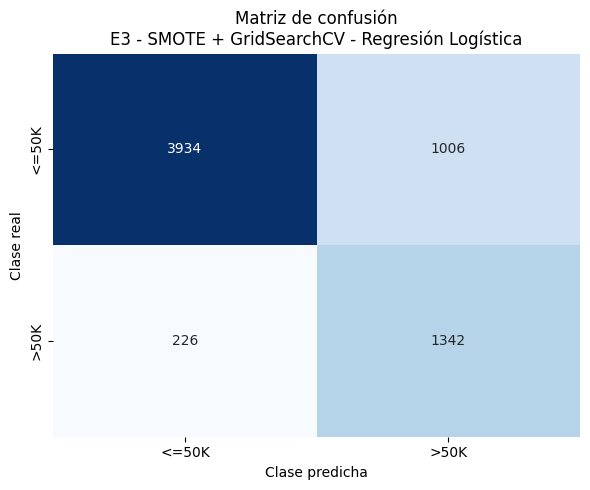

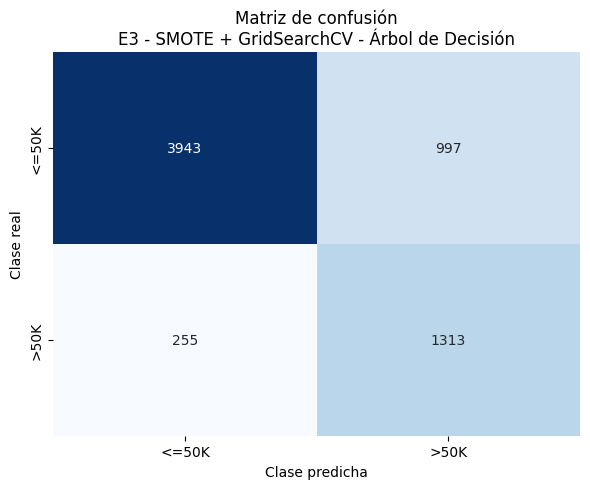

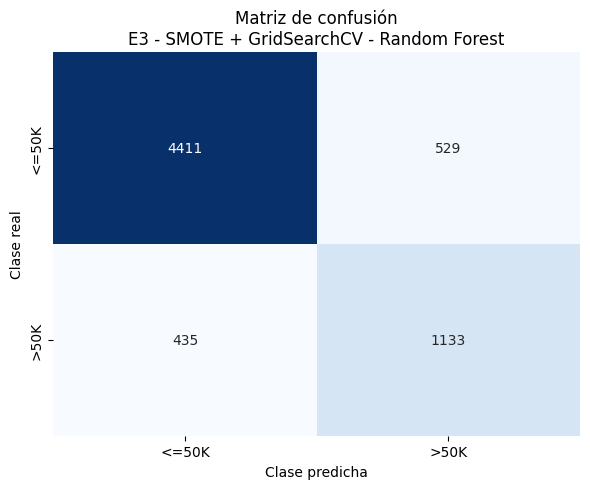

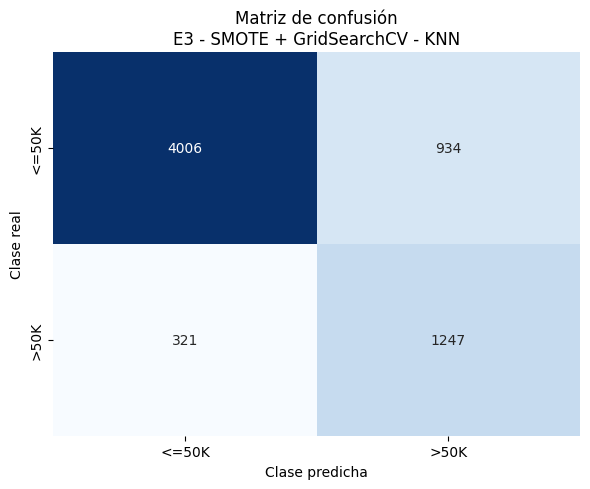

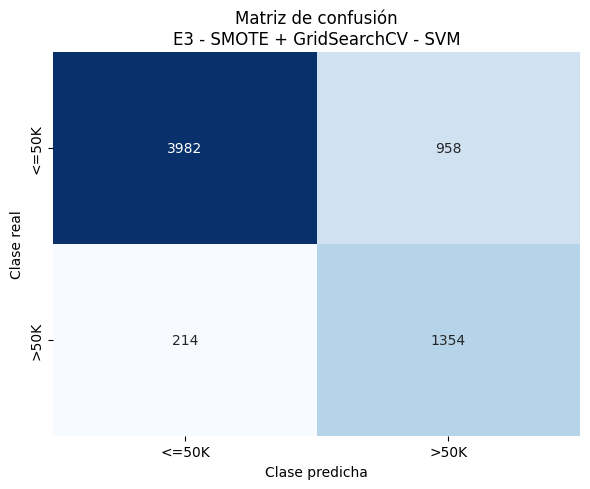

In [69]:
# ============================================================
# EXPERIMENTO 3
# MATRICES DE CONFUSIÓN
# ============================================================

for nombre, matriz in matrices_experimento_3.items():

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"]
    )

    plt.title(
        f"Matriz de confusión\n"
        f"E3 - SMOTE + GridSearchCV - {nombre}"
    )

    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.show()

In [70]:
# ============================================================
# COMPARACIÓN FINAL
# EXPERIMENTO 1 VS EXPERIMENTO 2 VS EXPERIMENTO 3
# ============================================================

columnas_comparacion_final = [
    "Experimento",
    "Modelo",
    "Accuracy",
    "Precision_>50K",
    "Recall_>50K",
    "F1_>50K",
    "MCC",
    "CV_Accuracy_Media",
    "CV_F1_Media",
    "CV_MCC_Media"
]

tabla_resultados_totales = pd.concat(
    [
        tabla_experimento_1[
            columnas_comparacion_final
        ],

        tabla_experimento_2[
            columnas_comparacion_final
        ],

        tabla_experimento_3[
            columnas_comparacion_final
        ]
    ],
    ignore_index=True
)

tabla_resultados_totales = (
    tabla_resultados_totales.sort_values(
        by=[
            "MCC",
            "F1_>50K",
            "Recall_>50K",
            "Accuracy"
        ],
        ascending=False
    ).reset_index(drop=True)
)

display(
    tabla_resultados_totales.round(4)
)

,Experimento,Modelo,Accuracy,Precision_>50K,Recall_>50K,F1_>50K,MCC,CV_Accuracy_Media,CV_F1_Media,CV_MCC_Media
0,E2 - SMOTE,Random Forest,0.8519,0.6817,0.7226,0.7015,0.6036,0.8433,0.6786,0.5751
1,E3 - SMOTE + GridSearchCV,Random Forest,0.8519,0.6817,0.7226,0.7015,0.6036,0.8433,0.6786,0.5751
2,E1 - Original,Random Forest,0.8603,0.7464,0.6365,0.6871,0.6011,0.8517,0.6667,0.5755
3,E2 - SMOTE,SVM,0.8199,0.5856,0.8635,0.6979,0.5983,0.8143,0.6869,0.5819
4,E3 - SMOTE + GridSearchCV,SVM,0.8199,0.5856,0.8635,0.6979,0.5983,0.8143,0.6869,0.5819
5,E1 - Original,SVM,0.8589,0.7673,0.5950,0.6703,0.5900,0.8549,0.6566,0.5761
6,E1 - Original,Regresión Logística,0.8571,0.7443,0.6199,0.6764,0.5897,0.8493,0.6538,0.5641
7,E2 - SMOTE,Regresión Logística,0.8107,0.5716,0.8559,0.6854,0.5808,0.8079,0.6786,0.5703
8,E3 - SMOTE + GridSearchCV,Regresión Logística,0.8107,0.5716,0.8559,0.6854,0.5808,0.8079,0.6786,0.5703
9,E3 - SMOTE + GridSearchCV,Árbol de Decisión,0.8076,0.5684,0.8374,0.6772,0.5680,0.8041,0.6696,0.5568


In [71]:
# ============================================================
# SELECCIÓN DEL MEJOR MODELO GENERAL
# ============================================================

mejor_modelo_general = tabla_resultados_totales.iloc[0]

print("=" * 78)
print("MEJOR RESULTADO ENTRE LOS TRES EXPERIMENTOS")
print("=" * 78)

print(
    "Experimento              :",
    mejor_modelo_general["Experimento"]
)

print(
    "Modelo                   :",
    mejor_modelo_general["Modelo"]
)

print(
    f"Accuracy                 : "
    f"{mejor_modelo_general['Accuracy']:.4f}"
)

print(
    f"Precision de >50K        : "
    f"{mejor_modelo_general['Precision_>50K']:.4f}"
)

print(
    f"Recall de >50K           : "
    f"{mejor_modelo_general['Recall_>50K']:.4f}"
)

print(
    f"F1-score de >50K         : "
    f"{mejor_modelo_general['F1_>50K']:.4f}"
)

print(
    f"MCC                      : "
    f"{mejor_modelo_general['MCC']:.4f}"
)

print(
    f"CV F1                    : "
    f"{mejor_modelo_general['CV_F1_Media']:.4f}"
)

print(
    f"CV MCC                   : "
    f"{mejor_modelo_general['CV_MCC_Media']:.4f}"
)

MEJOR RESULTADO ENTRE LOS TRES EXPERIMENTOS
Experimento              : E2 - SMOTE
Modelo                   : Random Forest
Accuracy                 : 0.8519
Precision de >50K        : 0.6817
Recall de >50K           : 0.7226
F1-score de >50K         : 0.7015
MCC                      : 0.6036
CV F1                    : 0.6786
CV MCC                   : 0.5751


# FASE VI. INTERPRETACIÓN DEL MODELO FINAL

Después de comparar los tres experimentos, Random Forest con SMOTE fue
seleccionado como modelo final debido a que obtuvo el mayor MCC y el mayor
F1-score para la clase >50K.

La optimización con GridSearchCV seleccionó una configuración equivalente,
por lo que no se observó una mejora adicional respecto al Experimento 2.

En esta fase se realizará:

1. Verificación del modelo final.
2. Análisis detallado de la matriz de confusión.
3. Importancia de variables mediante Permutation Importance.
4. Importancia interna de Random Forest.
5. Análisis de falsos positivos y falsos negativos.
6. Ejemplos de predicción.
7. Exportación del modelo y los resultados.

In [72]:
# ============================================================
# FASE VI
# BLOQUE 1: SELECCIÓN DEL MODELO FINAL
# ============================================================

# ¿QUÉ SE HACE?
# Se recupera Random Forest entrenado con SMOTE.

# ¿PARA QUÉ SE HACE?
# Este modelo será utilizado para interpretar las variables,
# analizar errores y generar predicciones finales.

# ¿POR QUÉ SE ELIGE EL EXPERIMENTO 2?
# Random Forest obtuvo el mejor MCC y F1-score.
# GridSearchCV seleccionó una configuración equivalente, por lo
# que el Experimento 3 no produjo una mejora adicional.

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)

# ------------------------------------------------------------
# RECUPERACIÓN DEL MODELO
# ------------------------------------------------------------

if (
    "pipelines_experimento_2" in globals()
    and "Random Forest" in pipelines_experimento_2
):

    modelo_final = pipelines_experimento_2["Random Forest"]
    origen_modelo_final = "Experimento 2 - Random Forest + SMOTE"

elif (
    "pipelines_experimento_3" in globals()
    and "Random Forest" in pipelines_experimento_3
):

    # Esta alternativa es válida porque GridSearchCV seleccionó
    # la misma configuración utilizada en el Experimento 2.
    modelo_final = pipelines_experimento_3["Random Forest"]
    origen_modelo_final = (
        "Experimento 3 - Random Forest + SMOTE + GridSearchCV"
    )

elif os.path.exists("modelo_e3_random_forest.joblib"):

    modelo_final = joblib.load(
        "modelo_e3_random_forest.joblib"
    )

    origen_modelo_final = (
        "Modelo Random Forest recuperado desde archivo"
    )

else:

    raise FileNotFoundError(
        "No se encontró el modelo Random Forest. "
        "Ejecuta nuevamente los experimentos 2 y 3."
    )

# ------------------------------------------------------------
# PREDICCIÓN FINAL
# ------------------------------------------------------------

y_pred_final = modelo_final.predict(X_test)

if hasattr(modelo_final, "predict_proba"):

    probabilidades_finales = modelo_final.predict_proba(
        X_test
    )[:, 1]

else:

    probabilidades_finales = np.full(
        len(X_test),
        np.nan
    )

# ------------------------------------------------------------
# MÉTRICAS DE VERIFICACIÓN
# ------------------------------------------------------------

metricas_modelo_final = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_final
    ),

    "Precision_>50K": precision_score(
        y_test,
        y_pred_final,
        pos_label=1,
        zero_division=0
    ),

    "Recall_>50K": recall_score(
        y_test,
        y_pred_final,
        pos_label=1,
        zero_division=0
    ),

    "F1_>50K": f1_score(
        y_test,
        y_pred_final,
        pos_label=1,
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_test,
        y_pred_final
    )
}

tabla_metricas_modelo_final = pd.DataFrame(
    [metricas_modelo_final]
)

print("=" * 75)
print("MODELO FINAL SELECCIONADO")
print("=" * 75)
print("Origen:", origen_modelo_final)

display(
    tabla_metricas_modelo_final.round(4)
)

# Guardar el modelo final.
joblib.dump(
    modelo_final,
    "modelo_final_random_forest_smote.joblib"
)

print(
    "\nModelo guardado en: "
    "modelo_final_random_forest_smote.joblib"
)

MODELO FINAL SELECCIONADO
Origen: Experimento 2 - Random Forest + SMOTE


,Accuracy,Precision_>50K,Recall_>50K,F1_>50K,MCC
0,0.8519,0.6817,0.7226,0.7015,0.6036



Modelo guardado en: modelo_final_random_forest_smote.joblib


In [73]:
# ============================================================
# FASE VI
# BLOQUE 2: ANÁLISIS DE LA MATRIZ DE CONFUSIÓN
# ============================================================

# ¿QUÉ SE HACE?
# Se separan los verdaderos negativos, falsos positivos,
# falsos negativos y verdaderos positivos.

# ¿PARA QUÉ SE HACE?
# Para conocer exactamente qué tipos de errores comete el modelo.

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_final
).ravel()

especificidad = tn / (tn + fp)
tasa_falsos_positivos = fp / (fp + tn)
tasa_falsos_negativos = fn / (fn + tp)
valor_predictivo_negativo = tn / (tn + fn)
balanced_accuracy = (
    metricas_modelo_final["Recall_>50K"]
    + especificidad
) / 2

tabla_matriz_detallada = pd.DataFrame({
    "Componente": [
        "Verdaderos negativos",
        "Falsos positivos",
        "Falsos negativos",
        "Verdaderos positivos"
    ],

    "Significado": [
        "<=50K clasificados correctamente",
        "<=50K clasificados como >50K",
        ">50K clasificados como <=50K",
        ">50K clasificados correctamente"
    ],

    "Cantidad": [
        tn,
        fp,
        fn,
        tp
    ]
})

display(tabla_matriz_detallada)

tabla_tasas_modelo = pd.DataFrame({
    "Indicador": [
        "Sensibilidad / Recall >50K",
        "Especificidad <=50K",
        "Tasa de falsos positivos",
        "Tasa de falsos negativos",
        "Valor predictivo negativo",
        "Balanced Accuracy"
    ],

    "Valor": [
        metricas_modelo_final["Recall_>50K"],
        especificidad,
        tasa_falsos_positivos,
        tasa_falsos_negativos,
        valor_predictivo_negativo,
        balanced_accuracy
    ]
})

display(
    tabla_tasas_modelo.round(4)
)

,Componente,Significado,Cantidad
0,Verdaderos negativos,<=50K clasificados correctamente,4411
1,Falsos positivos,<=50K clasificados como >50K,529
2,Falsos negativos,>50K clasificados como <=50K,435
3,Verdaderos positivos,>50K clasificados correctamente,1133


,Indicador,Valor
0,Sensibilidad / Recall >50K,0.7226
1,Especificidad <=50K,0.8929
2,Tasa de falsos positivos,0.1071
3,Tasa de falsos negativos,0.2774
4,Valor predictivo negativo,0.9102
5,Balanced Accuracy,0.8077


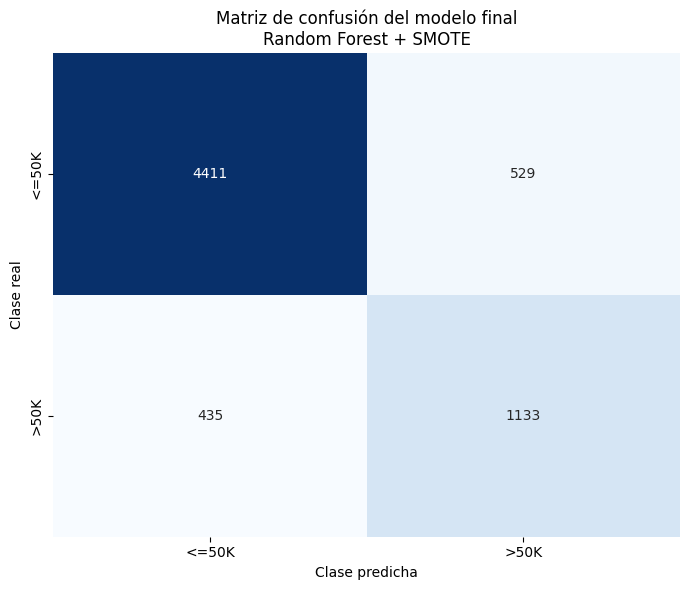

In [74]:
# ============================================================
# FASE VI
# BLOQUE 3: MATRIZ DE CONFUSIÓN DEL MODELO FINAL
# ============================================================

# ¿QUÉ SE HACE?
# Se presenta gráficamente la matriz de confusión.

# ¿PARA QUÉ SE HACE?
# Para observar los aciertos y errores en ambas clases.

matriz_final = np.array([
    [tn, fp],
    [fn, tp]
])

plt.figure(figsize=(7, 6))

sns.heatmap(
    matriz_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)

plt.title(
    "Matriz de confusión del modelo final\n"
    "Random Forest + SMOTE"
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()

plt.savefig(
    "matriz_confusion_modelo_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [75]:
# ============================================================
# FASE VI
# BLOQUE 4: PERMUTATION IMPORTANCE
# ============================================================

# ¿QUÉ SE HACE?
# Se altera aleatoriamente una variable por vez y se mide cuánto
# disminuye el MCC del modelo.

# ¿PARA QUÉ SE HACE?
# Si al desordenar una variable el MCC disminuye considerablemente,
# significa que el modelo depende de esa variable para clasificar.

# ¿POR QUÉ SE UTILIZA ESTE MÉTODO?
# Permutation Importance permite medir la importancia directamente
# sobre el conjunto de prueba y conserva las variables originales,
# antes del One-Hot Encoding.

from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

mcc_scorer = make_scorer(
    matthews_corrcoef
)

print("Calculando importancia por permutación...")

resultado_permutacion = permutation_importance(
    estimator=modelo_final,
    X=X_test,
    y=y_test,
    scoring=mcc_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=1
)

tabla_importancia_permutacion = pd.DataFrame({
    "Variable": X_test.columns,

    "Importancia_Media_MCC": (
        resultado_permutacion.importances_mean
    ),

    "Desviacion_Estandar": (
        resultado_permutacion.importances_std
    )
})

tabla_importancia_permutacion[
    "Limite_Inferior_Aprox"
] = (
    tabla_importancia_permutacion[
        "Importancia_Media_MCC"
    ]
    -
    2
    * tabla_importancia_permutacion[
        "Desviacion_Estandar"
    ]
)

tabla_importancia_permutacion[
    "Limite_Superior_Aprox"
] = (
    tabla_importancia_permutacion[
        "Importancia_Media_MCC"
    ]
    +
    2
    * tabla_importancia_permutacion[
        "Desviacion_Estandar"
    ]
)

tabla_importancia_permutacion = (
    tabla_importancia_permutacion.sort_values(
        by="Importancia_Media_MCC",
        ascending=False
    ).reset_index(drop=True)
)

tabla_importancia_permutacion.insert(
    0,
    "Posicion",
    range(
        1,
        len(tabla_importancia_permutacion) + 1
    )
)

display(
    tabla_importancia_permutacion.round(6)
)

Calculando importancia por permutación...


,Posicion,Variable,Importancia_Media_MCC,Desviacion_Estandar,Limite_Inferior_Aprox,Limite_Superior_Aprox
0,1,Marital_status,0.126606,0.007604,0.111398,0.141813
1,2,Capital_gain,0.085167,0.005424,0.074319,0.096016
2,3,Age,0.063573,0.006548,0.050477,0.076668
3,4,Occupation,0.055364,0.005356,0.044651,0.066077
4,5,Relationship,0.032886,0.004659,0.023569,0.042203
5,6,Education_num,0.032692,0.006690,0.019312,0.046071
6,7,Hours_per_week,0.025510,0.007777,0.009957,0.041064
7,8,Capital_loss,0.023321,0.001728,0.019865,0.026778
8,9,Workclass,0.010373,0.003795,0.002784,0.017962
9,10,Race,0.006596,0.003189,0.000218,0.012973


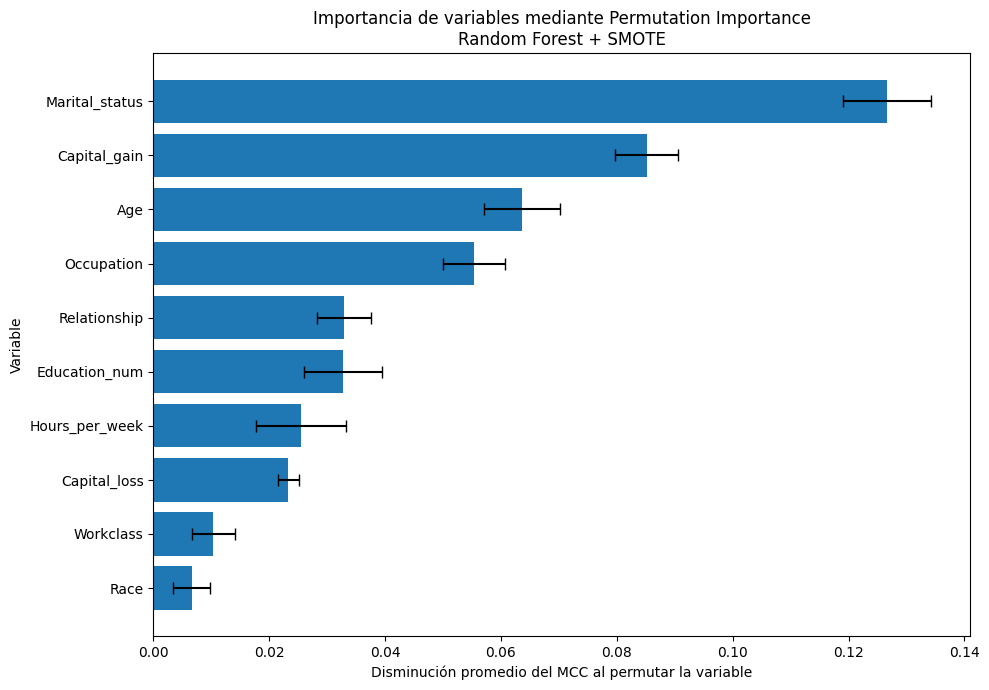

In [76]:
# ============================================================
# FASE VI
# BLOQUE 5: GRÁFICO DE IMPORTANCIA
# ============================================================

# ¿QUÉ SE HACE?
# Se representan las diez variables cuya alteración produjo
# la mayor disminución del MCC.

top_importancia = (
    tabla_importancia_permutacion
    .head(10)
    .sort_values(
        by="Importancia_Media_MCC",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_importancia["Variable"],
    top_importancia["Importancia_Media_MCC"],
    xerr=top_importancia["Desviacion_Estandar"],
    capsize=4
)

plt.title(
    "Importancia de variables mediante Permutation Importance\n"
    "Random Forest + SMOTE"
)

plt.xlabel(
    "Disminución promedio del MCC al permutar la variable"
)

plt.ylabel("Variable")
plt.tight_layout()

plt.savefig(
    "importancia_variables_permutacion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
# ============================================================
# FASE VI
# BLOQUE 6: IMPORTANCIA INTERNA DE RANDOM FOREST
# ============================================================

# ¿QUÉ SE HACE?
# Se obtiene la importancia interna calculada por los árboles
# mediante reducción promedio de impureza.

# ¿PARA QUÉ SE HACE?
# Para complementar Permutation Importance y comprobar si ambos
# métodos identifican variables similares.

# IMPORTANTE:
# Este método puede favorecer variables con muchas categorías.
# Por ello, Permutation Importance será el análisis principal.

preprocesador_final = modelo_final.named_steps[
    "preprocesamiento"
]

random_forest_final = modelo_final.named_steps[
    "modelo"
]

nombres_transformados = (
    preprocesador_final.get_feature_names_out()
)

importancias_internas = (
    random_forest_final.feature_importances_
)

tabla_importancia_transformada = pd.DataFrame({
    "Caracteristica_Transformada": nombres_transformados,
    "Importancia_Interna": importancias_internas
})

# ------------------------------------------------------------
# IDENTIFICAR LA VARIABLE ORIGINAL
# ------------------------------------------------------------

def obtener_variable_original(nombre_transformado):

    nombre_limpio = nombre_transformado.split(
        "__",
        1
    )[-1]

    # Variables numéricas.
    if nombre_limpio in variables_numericas:
        return nombre_limpio

    # Variables categóricas después del One-Hot Encoding.
    for variable in sorted(
        variables_categoricas,
        key=len,
        reverse=True
    ):

        if nombre_limpio.startswith(
            variable + "_"
        ):
            return variable

    return nombre_limpio


tabla_importancia_transformada[
    "Variable"
] = tabla_importancia_transformada[
    "Caracteristica_Transformada"
].apply(
    obtener_variable_original
)

# Se suman las importancias de todas las categorías generadas
# a partir de una misma variable original.
tabla_importancia_interna = (
    tabla_importancia_transformada.groupby(
        "Variable",
        as_index=False
    )["Importancia_Interna"]
    .sum()
    .sort_values(
        by="Importancia_Interna",
        ascending=False
    )
    .reset_index(drop=True)
)

tabla_importancia_interna.insert(
    0,
    "Posicion_Interna",
    range(
        1,
        len(tabla_importancia_interna) + 1
    )
)

display(
    tabla_importancia_interna.round(6)
)

,Posicion_Interna,Variable,Importancia_Interna
0,1,Marital_status,0.190635
1,2,Age,0.151226
2,3,fnlwgt,0.112853
3,4,Occupation,0.091928
4,5,Hours_per_week,0.088357
5,6,Relationship,0.077476
6,7,Education_num,0.069461
7,8,Capital_gain,0.051678
8,9,Education,0.050865
9,10,Workclass,0.037216


In [78]:
# ============================================================
# FASE VI
# BLOQUE 7: COMPARACIÓN DE MÉTODOS DE IMPORTANCIA
# ============================================================

# ¿QUÉ SE HACE?
# Se comparan Permutation Importance y feature_importances_.

# ¿PARA QUÉ SE HACE?
# Para identificar variables que aparecen como relevantes
# mediante dos métodos diferentes.

tabla_importancia_comparada = (
    tabla_importancia_permutacion[
        [
            "Variable",
            "Posicion",
            "Importancia_Media_MCC",
            "Desviacion_Estandar"
        ]
    ]
    .merge(
        tabla_importancia_interna[
            [
                "Variable",
                "Posicion_Interna",
                "Importancia_Interna"
            ]
        ],
        on="Variable",
        how="left"
    )
)

tabla_importancia_comparada = (
    tabla_importancia_comparada.rename(
        columns={
            "Posicion": "Ranking_Permutacion",
            "Posicion_Interna": "Ranking_Interno"
        }
    )
)

display(
    tabla_importancia_comparada.round(6)
)

,Variable,Ranking_Permutacion,Importancia_Media_MCC,Desviacion_Estandar,Ranking_Interno,Importancia_Interna
0,Marital_status,1,0.126606,0.007604,1,0.190635
1,Capital_gain,2,0.085167,0.005424,8,0.051678
2,Age,3,0.063573,0.006548,2,0.151226
3,Occupation,4,0.055364,0.005356,4,0.091928
4,Relationship,5,0.032886,0.004659,6,0.077476
5,Education_num,6,0.032692,0.006690,7,0.069461
6,Hours_per_week,7,0.025510,0.007777,5,0.088357
7,Capital_loss,8,0.023321,0.001728,13,0.017211
8,Workclass,9,0.010373,0.003795,10,0.037216
9,Race,10,0.006596,0.003189,14,0.016766


In [79]:
# ============================================================
# FASE VI
# BLOQUE 8: ANÁLISIS DE ERRORES
# ============================================================

# ¿QUÉ SE HACE?
# Se identifican los registros clasificados correctamente y
# aquellos que fueron confundidos por el modelo.

# ¿PARA QUÉ SE HACE?
# Para comprender en qué situaciones se producen falsos
# positivos y falsos negativos.

analisis_errores = X_test.copy()

analisis_errores[
    "Clase_real"
] = y_test.values

analisis_errores[
    "Clase_predicha"
] = y_pred_final

analisis_errores[
    "Probabilidad_>50K"
] = probabilidades_finales

condiciones = [
    (
        (analisis_errores["Clase_real"] == 0)
        &
        (analisis_errores["Clase_predicha"] == 0)
    ),

    (
        (analisis_errores["Clase_real"] == 0)
        &
        (analisis_errores["Clase_predicha"] == 1)
    ),

    (
        (analisis_errores["Clase_real"] == 1)
        &
        (analisis_errores["Clase_predicha"] == 0)
    ),

    (
        (analisis_errores["Clase_real"] == 1)
        &
        (analisis_errores["Clase_predicha"] == 1)
    )
]

tipos_resultado = [
    "Verdadero negativo",
    "Falso positivo",
    "Falso negativo",
    "Verdadero positivo"
]

analisis_errores[
    "Tipo_resultado"
] = np.select(
    condiciones,
    tipos_resultado,
    default="No identificado"
)

resumen_errores = (
    analisis_errores[
        "Tipo_resultado"
    ]
    .value_counts()
    .rename_axis("Tipo_resultado")
    .reset_index(name="Cantidad")
)

resumen_errores[
    "Porcentaje"
] = (
    resumen_errores["Cantidad"]
    / len(analisis_errores)
    * 100
)

display(
    resumen_errores.round(2)
)

,Tipo_resultado,Cantidad,Porcentaje
0,Verdadero negativo,4411,67.78
1,Verdadero positivo,1133,17.41
2,Falso positivo,529,8.13
3,Falso negativo,435,6.68


In [80]:
# ============================================================
# FASE VI
# BLOQUE 9: EJEMPLOS DE ERRORES
# ============================================================

# ¿QUÉ SE HACE?
# Se muestran algunos casos donde el modelo se equivocó.

# ¿PARA QUÉ SE HACE?
# Para analizar las características de personas difíciles
# de clasificar.

columnas_para_analisis = [
    "Age",
    "Education",
    "Education_num",
    "Marital_status",
    "Occupation",
    "Capital_gain",
    "Capital_loss",
    "Hours_per_week",
    "Clase_real",
    "Clase_predicha",
    "Probabilidad_>50K",
    "Tipo_resultado"
]

falsos_positivos = analisis_errores[
    analisis_errores[
        "Tipo_resultado"
    ] == "Falso positivo"
].copy()

falsos_negativos = analisis_errores[
    analisis_errores[
        "Tipo_resultado"
    ] == "Falso negativo"
].copy()

print("EJEMPLOS DE FALSOS POSITIVOS")

display(
    falsos_positivos[
        columnas_para_analisis
    ]
    .sort_values(
        by="Probabilidad_>50K",
        ascending=False
    )
    .head(10)
)

print("\nEJEMPLOS DE FALSOS NEGATIVOS")

display(
    falsos_negativos[
        columnas_para_analisis
    ]
    .sort_values(
        by="Probabilidad_>50K",
        ascending=True
    )
    .head(10)
)

EJEMPLOS DE FALSOS POSITIVOS


,Age,Education,Education_num,Marital_status,Occupation,Capital_gain,Capital_loss,Hours_per_week,Clase_real,Clase_predicha,Probabilidad_>50K,Tipo_resultado
1303,36,Prof-school,15,Married-civ-spouse,Prof-specialty,0,0,50,0,1,1.00,Falso positivo
12096,55,HS-grad,9,Married-civ-spouse,Craft-repair,0,0,40,0,1,1.00,Falso positivo
10976,35,Prof-school,15,Married-civ-spouse,Prof-specialty,0,0,55,0,1,0.99,Falso positivo
4788,37,Masters,14,Married-civ-spouse,Prof-specialty,0,0,45,0,1,0.99,Falso positivo
31529,33,Bachelors,13,Married-civ-spouse,Exec-managerial,0,0,40,0,1,0.99,Falso positivo
20394,37,Bachelors,13,Married-civ-spouse,Prof-specialty,0,0,40,0,1,0.99,Falso positivo
10144,43,HS-grad,9,Married-civ-spouse,Exec-managerial,0,0,40,0,1,0.99,Falso positivo
15544,38,Bachelors,13,Married-civ-spouse,Prof-specialty,0,0,50,0,1,0.99,Falso positivo
2799,36,Bachelors,13,Married-civ-spouse,Prof-specialty,0,0,38,0,1,0.98,Falso positivo
31054,50,Masters,14,Married-civ-spouse,Sales,0,0,55,0,1,0.98,Falso positivo



EJEMPLOS DE FALSOS NEGATIVOS


,Age,Education,Education_num,Marital_status,Occupation,Capital_gain,Capital_loss,Hours_per_week,Clase_real,Clase_predicha,Probabilidad_>50K,Tipo_resultado
27503,34,Some-college,10,Married-civ-spouse,Handlers-cleaners,0,0,40,1,0,0.00,Falso negativo
31490,27,HS-grad,9,Never-married,Other-service,0,0,50,1,0,0.00,Falso negativo
30928,45,HS-grad,9,Divorced,Exec-managerial,0,0,38,1,0,0.00,Falso negativo
19990,30,HS-grad,9,Married-civ-spouse,Craft-repair,0,0,40,1,0,0.00,Falso negativo
22380,36,HS-grad,9,Married-civ-spouse,Craft-repair,0,0,40,1,0,0.00,Falso negativo
23289,66,HS-grad,9,Widowed,Adm-clerical,0,0,35,1,0,0.00,Falso negativo
1203,44,Bachelors,13,Never-married,Other-service,0,0,40,1,0,0.00,Falso negativo
8970,55,HS-grad,9,Divorced,Adm-clerical,0,0,40,1,0,0.00,Falso negativo
22897,23,Some-college,10,Never-married,Protective-serv,0,0,40,1,0,0.00,Falso negativo
31559,27,HS-grad,9,Married-civ-spouse,Craft-repair,0,0,45,1,0,0.01,Falso negativo


In [81]:
# ============================================================
# FASE VI
# BLOQUE 10: EJEMPLOS DE PREDICCIÓN
# ============================================================

# ¿QUÉ SE HACE?
# Se selecciona un caso correctamente clasificado de cada clase.

# ¿PARA QUÉ SE HACE?
# Para mostrar de forma práctica cómo funciona el modelo final.

caso_menor_igual_50k = analisis_errores[
    analisis_errores[
        "Tipo_resultado"
    ] == "Verdadero negativo"
].head(1)

caso_mayor_50k = analisis_errores[
    analisis_errores[
        "Tipo_resultado"
    ] == "Verdadero positivo"
].head(1)

ejemplos_prediccion = pd.concat(
    [
        caso_menor_igual_50k,
        caso_mayor_50k
    ]
)

ejemplos_prediccion[
    "Clase_real_texto"
] = ejemplos_prediccion[
    "Clase_real"
].map({
    0: "<=50K",
    1: ">50K"
})

ejemplos_prediccion[
    "Clase_predicha_texto"
] = ejemplos_prediccion[
    "Clase_predicha"
].map({
    0: "<=50K",
    1: ">50K"
})

display(
    ejemplos_prediccion[
        [
            "Age",
            "Education",
            "Education_num",
            "Occupation",
            "Capital_gain",
            "Capital_loss",
            "Hours_per_week",
            "Clase_real_texto",
            "Clase_predicha_texto",
            "Probabilidad_>50K"
        ]
    ].round(4)
)

,Age,Education,Education_num,Occupation,Capital_gain,Capital_loss,Hours_per_week,Clase_real_texto,Clase_predicha_texto,Probabilidad_>50K
20325,27,Masters,14,Machine-op-inspct,0,0,40,<=50K,<=50K,0.09
23863,51,Bachelors,13,Adm-clerical,0,0,50,>50K,>50K,0.71


In [82]:
# ============================================================
# FASE VI
# BLOQUE 11: EXPORTACIÓN DE RESULTADOS
# ============================================================

# ¿QUÉ SE HACE?
# Se guardan las tablas utilizadas para la interpretación.

# ¿PARA QUÉ SE HACE?
# Estos archivos servirán para elaborar las tablas y figuras
# definitivas del artículo científico.

tabla_metricas_modelo_final.to_csv(
    "metricas_modelo_final.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_matriz_detallada.to_csv(
    "matriz_confusion_detallada.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_tasas_modelo.to_csv(
    "tasas_evaluacion_modelo_final.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_importancia_permutacion.to_csv(
    "importancia_variables_permutacion.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_importancia_interna.to_csv(
    "importancia_variables_random_forest.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_importancia_comparada.to_csv(
    "comparacion_metodos_importancia.csv",
    index=False,
    encoding="utf-8-sig"
)

resumen_errores.to_csv(
    "resumen_errores_modelo_final.csv",
    index=False,
    encoding="utf-8-sig"
)

analisis_errores.to_csv(
    "analisis_detallado_predicciones.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivos de la Fase VI exportados correctamente.")
print("Modelo final guardado correctamente.")

Archivos de la Fase VI exportados correctamente.
Modelo final guardado correctamente.
